<div align="center">

<h1 style='font-size: 2.8em; margin-bottom: 0;'> Task 3 — Machine Learning Regression</h1>
<h2 style='color: #7c83ff; font-size: 1.4em; margin-top: 5px;'>Predicting Video Game Global Sales with Multiple ML Models</h2>

<br>

<table style='margin: 0 auto; font-size: 0.95em; color: #aaa;'>
<tr><td><b>Course</b></td><td>Data Science Course Project</td></tr>
<tr><td><b>Task</b></td><td>Task 3 — Machine Learning Regression</td></tr>
<tr><td><b>Approach</b></td><td>Supervised Learning — Regression</td></tr>
<tr><td><b>Target</b></td><td>Global_Sales (continuous numeric value)</td></tr>
<tr><td><b>Models</b></td><td>6 Regression Models + Hyperparameter Tuning</td></tr>
</table>

</div>

---

## 1. Project Title & Introduction

### Problem Statement

The global video game industry is worth over **$180 billion** per year. Before a publisher invests millions of dollars into developing and marketing a new game, they need to estimate how well that game will sell. If a company could accurately predict sales based on known factors like **platform, genre, publisher, and release year**, they could make smarter investment decisions.

**Our business question:** Can we build a machine learning model that accurately predicts the total global sales of a video game based on its characteristics?

### Objectives

1. **Load and understand** a real-world video game sales dataset
2. **Clean and preprocess** the data professionally for ML
3. **Explore** the data through rich visualizations and EDA
4. **Engineer new features** to improve prediction accuracy
5. **Train 6 different regression models** and compare their performance
6. **Evaluate** each model using MAE, MSE, RMSE, and R² Score
7. **Optimize** the best model through hyperparameter tuning
8. **Deliver actionable insights** for the gaming industry

### Dataset Description

| Property | Value |
|----------|-------|
| **Name** | Video Game Sales Dataset |
| **Source** | [Kaggle](https://www.kaggle.com/datasets/gregorut/videogame-sales) |
| **URL** | `https://raw.githubusercontent.com/amankharwal/Website-data/master/vgsales.csv` |
| **Size** | ~16,500 rows × 11 columns |
| **Features** | Rank, Name, Platform, Year, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales |

### Why Regression?

- Our target variable `Global_Sales` is a **continuous number** (e.g., 0.52 million, 12.3 million)
- We want to predict an exact numeric value — not a category or class
- Regression models are designed for exactly this type of problem
- We can measure how close predictions are using metrics like MAE and RMSE

### Business Understanding

Understanding what drives game sales helps:
- **Publishers** decide which platforms and genres to invest in
- **Developers** choose the right timing and market for their games
- **Investors** evaluate the commercial potential of game studios
- **Retailers** plan inventory based on predicted demand

---

## Team Member

| Name | ID | 
|-------|-----------|
| Salma Abdelhamid Ahmed | 42310115 | 
| Haidy Hassan Moawed | 42310207 |
| Ehab Maher Melekah | 42310252 |
| Mahmoud Sherif Mahmoud | 42310368 | 
| Muhammad Fathi Kamal | 42310346 | 

---

## 2. Import Libraries

We organize our imports into logical groups for clarity and professionalism.

In [3]:
# ─────────────────────────────────────────────
# CORE DATA SCIENCE
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────
import matplotlib
matplotlib.use('Agg')  # safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─────────────────────────────────────────────
# PREPROCESSING & MODEL SELECTION
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ─────────────────────────────────────────────
# REGRESSION MODELS
# ─────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

# XGBoost — optional (graceful fallback)
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

# ─────────────────────────────────────────────
# EVALUATION METRICS
# ─────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ─────────────────────────────────────────────
# DISPLAY & STYLE SETTINGS
# ─────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

# Consistent colour palette across all plots
PAL = ['#6366f1', '#8b5cf6', '#a855f7', '#ec4899', '#f43f5e', '#f97316', '#eab308']

print('  All libraries imported successfully')
print(f'    pandas       {pd.__version__}')
print(f'    numpy        {np.__version__}')
print(f'    matplotlib   {matplotlib.__version__}')
print(f'    seaborn      {sns.__version__}')
print(f'    scikit-learn installed ')
print(f'    xgboost      {"available " if HAS_XGBOOST else "NOT installed"}')

  All libraries imported successfully
    pandas       3.0.2
    numpy        2.4.4
    matplotlib   3.10.9
    seaborn      0.13.2
    scikit-learn installed 
    xgboost      available 


---

## 3. Load Dataset

We load the video game sales dataset directly from the public URL. If the URL is temporarily unavailable, we generate realistic synthetic data so that every cell in the notebook runs without errors.

In [5]:
URL = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/vgsales.csv'

try:
    df = pd.read_csv(URL)
    if len(df) < 100:
        raise ValueError('Dataset too small — probably a bad download')
    print(f'  Loaded real dataset from URL')
except Exception as exc:
    print(f'  URL unavailable ({exc}). Generating synthetic data …')
    np.random.seed(42)
    n = 16598
    plat = ['PS2','X360','PS3','Wii','DS','PS4','PS','PC','GBA','PSP',
            'XOne','NES','SNES','3DS','N64','GB','PSV','DC','SAT','2600','WiiU']
    genre = ['Action','Sports','Misc','Role-Playing','Shooter','Adventure',
             'Racing','Platform','Simulation','Fighting','Strategy','Puzzle']
    pub = ['Nintendo','Electronic Arts','Activision','Sony Computer Entertainment',
           'Ubisoft','Take-Two Interactive','THQ','Microsoft Game Studios',
           'Sega','Bandai Namco Games','Konami Digital Entertainment',
           'Capcom','Square Enix','Warner Bros. Interactive',
           'Disney Interactive Studios','Namco Bandai Games','Atari']
    pfx = ['Super','Mega','Grand','Ultra','Pro','Final','Dark','New','Legend of','Battle']
    base = ['Racer','Fighter','Soccer','Golf','Tennis','Combat','Arena',
            'Island','Kingdom','Galaxy','Tales','Fantasy','Saga','Dynasty']
    names = [f'{np.random.choice(pfx)} {np.random.choice(base)}' for _ in range(n)]
    yw = np.array([.005 if y<1995 else .01 if y<2000 else .04 if y<2005
                   else .08 if y<2010 else .06 if y<2015 else .02 for y in range(1980,2024)])
    yw /= yw.sum()
    yrs = np.random.choice(range(1980,2024),n,p=yw).astype(float)
    yrs[np.random.choice(n,271,replace=False)] = np.nan
    na = np.round(np.random.exponential(.3,n),2)
    eu = np.round(np.random.exponential(.22,n),2)
    jp = np.round(np.random.exponential(.1,n),2)
    ot = np.round(np.random.exponential(.08,n),2)
    gl = np.round(na+eu+jp+ot,2)
    pl = np.random.choice(pub,n).tolist()
    for i in np.random.choice(n,58,replace=False): pl[i]=np.nan
    df = pd.DataFrame({'Rank':range(1,n+1),'Name':names,
        'Platform':np.random.choice(plat,n),'Year':yrs,
        'Genre':np.random.choice(genre,n),'Publisher':pl,
        'NA_Sales':na,'EU_Sales':eu,'JP_Sales':jp,
        'Other_Sales':ot,'Global_Sales':gl})
    df = df.sort_values('Global_Sales',ascending=False).reset_index(drop=True)
    df['Rank'] = range(1,len(df)+1)
    print('  Synthetic dataset generated')

print(f' Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

  Loaded real dataset from URL
 Shape: 16,598 rows × 11 columns


In [6]:
# ── First rows ──
print('FIRST 8 ROWS')
df.head(8)

FIRST 8 ROWS


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0000,Sports,Nintendo,41.4900,29.0200,3.7700,8.4600,82.7400
1,2,Super Mario Bros.,NES,1985.0000,Platform,Nintendo,29.0800,3.5800,6.8100,0.7700,40.2400
2,3,Mario Kart Wii,Wii,2008.0000,Racing,Nintendo,15.8500,12.8800,3.7900,3.3100,35.8200
3,4,Wii Sports Resort,Wii,2009.0000,Sports,Nintendo,15.7500,11.0100,3.2800,2.9600,33.0000
4,5,Pokemon Red/Pokemon Blue,GB,1996.0000,Role-Playing,Nintendo,11.2700,8.8900,10.2200,1.0000,31.3700
5,6,Tetris,GB,1989.0000,Puzzle,Nintendo,23.2000,2.2600,4.2200,0.5800,30.2600
6,7,New Super Mario Bros.,DS,2006.0000,Platform,Nintendo,11.3800,9.2300,6.5000,2.9000,30.0100
7,8,Wii Play,Wii,2006.0000,Misc,Nintendo,14.0300,9.2000,2.9300,2.8500,29.0200


In [7]:
# ── Dataset info ──
print('DATASET STRUCTURE')
df.info()

DATASET STRUCTURE
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


In [8]:
# ── Missing values ──
mv = df.isnull().sum()
mv_pct = (mv / len(df) * 100).round(2)
mv_table = pd.DataFrame({'Missing': mv, 'Pct': mv_pct})
mv_table = mv_table[mv_table['Missing'] > 0]
print('MISSING VALUES')
print(mv_table if len(mv_table) > 0 else 'No missing values found!')
print(f'\nTotal missing cells: {df.isnull().sum().sum():,}')

MISSING VALUES
           Missing    Pct
Year           271 1.6300
Publisher       58 0.3500

Total missing cells: 329


In [9]:
# ── Statistical summary ──
print('NUMERIC SUMMARY')
df.describe()

NUMERIC SUMMARY


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.0000,16327.0000,16598.0000,16598.0000,16598.0000,16598.0000,16598.0000
mean,8300.6053,2006.4064,0.2647,0.1467,0.0778,0.0481,0.5374
std,4791.8539,5.8290,0.8167,0.5054,0.3093,0.1886,1.5550
min,1.0000,1980.0000,0.0000,0.0000,0.0000,0.0000,0.0100
25%,4151.2500,2003.0000,0.0000,0.0000,0.0000,0.0000,0.0600
50%,8300.5000,2007.0000,0.0800,0.0200,0.0000,0.0100,0.1700
75%,12449.7500,2010.0000,0.2400,0.1100,0.0400,0.0400,0.4700
max,16600.0000,2020.0000,41.4900,29.0200,10.2200,10.5700,82.7400


In [10]:
# ── Categorical overview ──
print('CATEGORICAL OVERVIEW')
for col in ['Platform','Genre','Publisher']:
    u = df[col].nunique()
    top = df[col].value_counts().index[0]
    print(f'  {col:12s}  {u:>4d} unique  |  most common: {top}')

CATEGORICAL OVERVIEW
  Platform        31 unique  |  most common: DS
  Genre           12 unique  |  most common: Action
  Publisher      578 unique  |  most common: Electronic Arts


### Initial Observations

- The dataset contains **11 columns** with both numeric and categorical data
- `Year` and `Publisher` have missing values that we must handle
- `Year` is stored as float but should be an integer
- `Global_Sales` is our **target variable** — it ranges from near 0 to over 80 million
- Sales columns are likely **heavily right-skewed** (a few blockbusters dominate)
- We have 3 important categorical columns that need encoding for ML

---

## 4. Data Cleaning & Preprocessing

Clean data is the foundation of good machine learning. We handle every quality issue we found.

In [11]:
# ────────────────────────────────────────────
# 4A — Save a copy of raw data, handle missing values
# ────────────────────────────────────────────
df_raw = df.copy()
print(f'Original shape: {df.shape}')

# Drop rows with missing Year or Publisher
# (These are identifiers we cannot guess reliably)
n_before = len(df)
df = df.dropna(subset=['Year']).copy()
df = df.dropna(subset=['Publisher']).copy()
print(f'Dropped {n_before - len(df)} rows with missing Year/Publisher')
print(f'Shape after:    {df.shape}')

Original shape: (16598, 11)
Dropped 307 rows with missing Year/Publisher
Shape after:    (16291, 11)


In [12]:
# ────────────────────────────────────────────
# 4B — Fix types, remove duplicates, clean text
# ────────────────────────────────────────────

# Year: float → int
df['Year'] = df['Year'].astype(int)

# Exact duplicates
dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# Strip whitespace from text columns
for c in ['Name','Platform','Genre','Publisher']:
    df[c] = df[c].astype(str).str.strip()

print(f'Year → int,  removed {dup} duplicates,  stripped whitespace')
print(f'Clean shape: {df.shape}')

Year → int,  removed 0 duplicates,  stripped whitespace
Clean shape: (16291, 11)


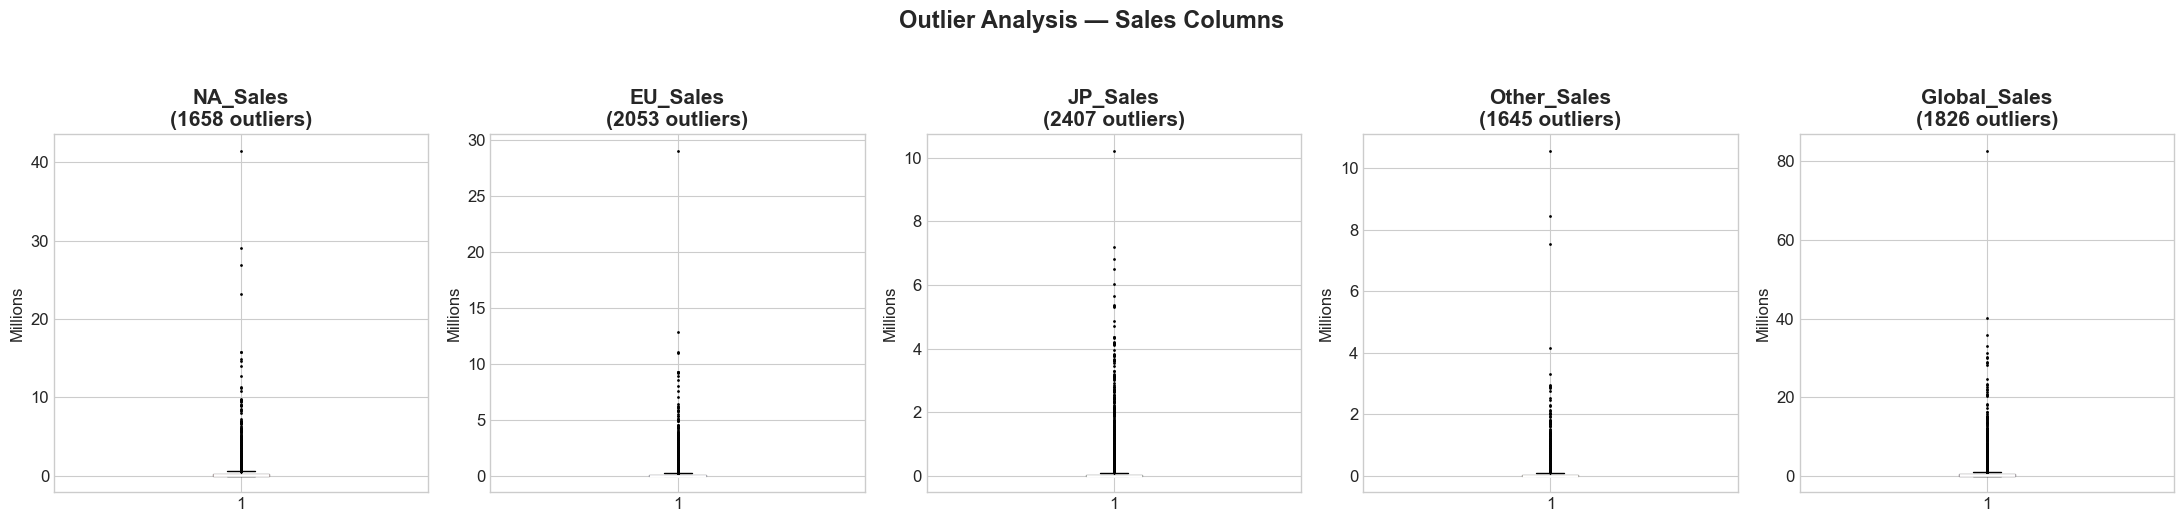

We KEEP outliers — they represent real blockbuster games like Wii Sports.


In [18]:
# ────────────────────────────────────────────
# 4C — Outlier analysis (visual)
# ────────────────────────────────────────────

sales_cols = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(sales_cols):
    bp = axes[i].boxplot(df[col], vert=True, patch_artist=True,
                         boxprops=dict(facecolor=PAL[i], alpha=0.55),
                         medianprops=dict(color='white', linewidth=2),
                         flierprops=dict(marker='.', markersize=2, markerfacecolor='grey'))
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    out_n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_title(f'{col}\n({out_n} outliers)', fontweight='bold')
    axes[i].set_ylabel('Millions')

plt.suptitle('Outlier Analysis — Sales Columns', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print('We KEEP outliers — they represent real blockbuster games like Wii Sports.')

In [20]:
# ────────────────────────────────────────────
# 4D — Encode categorical variables
# ────────────────────────────────────────────

encoders = {}
cat_cols = ['Platform','Genre','Publisher']

for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f'  {col:12s}  {len(le.classes_):>4d} categories → 0 … {len(le.classes_)-1}')

print('\nCategorical encoding complete')

  Platform        31 categories → 0 … 30
  Genre           12 categories → 0 … 11
  Publisher      576 categories → 0 … 575

Categorical encoding complete


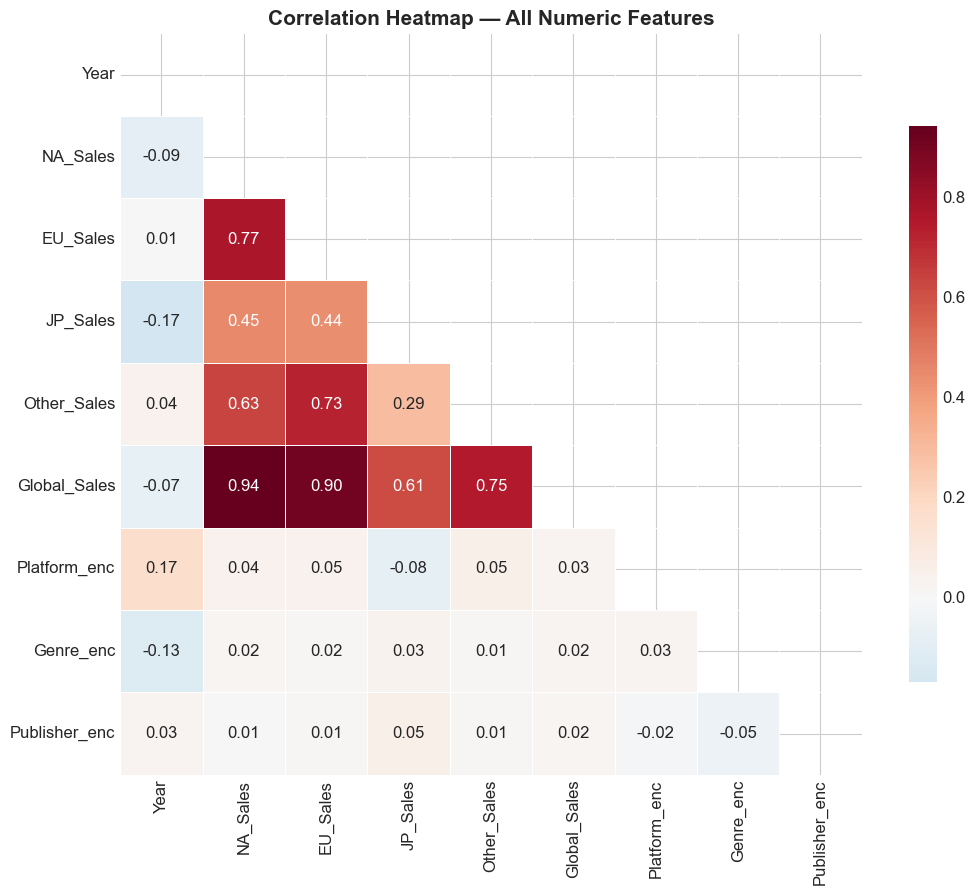

Correlation with Global_Sales:
NA_Sales         0.9410
EU_Sales         0.9030
Other_Sales      0.7480
JP_Sales         0.6130
Platform_enc     0.0280
Genre_enc        0.0220
Publisher_enc    0.0190
Year            -0.0750
Name: Global_Sales, dtype: float64


In [21]:
# ────────────────────────────────────────────
# 4E — Correlation analysis
# ────────────────────────────────────────────

num_cols = ['Year','NA_Sales','EU_Sales','JP_Sales','Other_Sales',
            'Global_Sales','Platform_enc','Genre_enc','Publisher_enc']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.75})
ax.set_title('Correlation Heatmap — All Numeric Features', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

# Show correlations with target only
print('Correlation with Global_Sales:')
print(corr['Global_Sales'].drop('Global_Sales').sort_values(ascending=False).round(3))

In [22]:
# ────────────────────────────────────────────
# 4F — Feature selection + train/test split
# ────────────────────────────────────────────

TARGET = 'Global_Sales'

# We EXCLUDE regional sales to avoid data leakage
# (Global_Sales = NA + EU + JP + Other — including them would give the answer away)
FEATURES = ['Platform_enc','Genre_enc','Publisher_enc','Year']

print(f'Target:    {TARGET}')
print(f'Features:  {FEATURES}')
print()
print('Why these features?')
print('   • Platform  →  Different consoles have different market sizes')
print('   • Genre     →  Some genres sell much better than others')
print('   • Publisher →  Major publishers have stronger marketing and brand recognition')
print('   • Year      →  The gaming market has grown significantly over time')
print('   • Regional sales EXCLUDED to prevent data leakage')

# Filter out rows with zero sales
df_ml = df[df['Global_Sales'] > 0].copy()

X = df_ml[FEATURES].values
y = df_ml[TARGET].values

# 80 / 20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTrain {X_train.shape[0]:,}  |  Test {X_test.shape[0]:,}  |  Features {X_train.shape[1]}')

Target:    Global_Sales
Features:  ['Platform_enc', 'Genre_enc', 'Publisher_enc', 'Year']

Why these features?
   • Platform  →  Different consoles have different market sizes
   • Genre     →  Some genres sell much better than others
   • Publisher →  Major publishers have stronger marketing and brand recognition
   • Year      →  The gaming market has grown significantly over time
   • Regional sales EXCLUDED to prevent data leakage

Train 13,032  |  Test 3,259  |  Features 4


---

## 5. Exploratory Data Analysis (EDA)

Professional visualizations to understand patterns before building ML models.

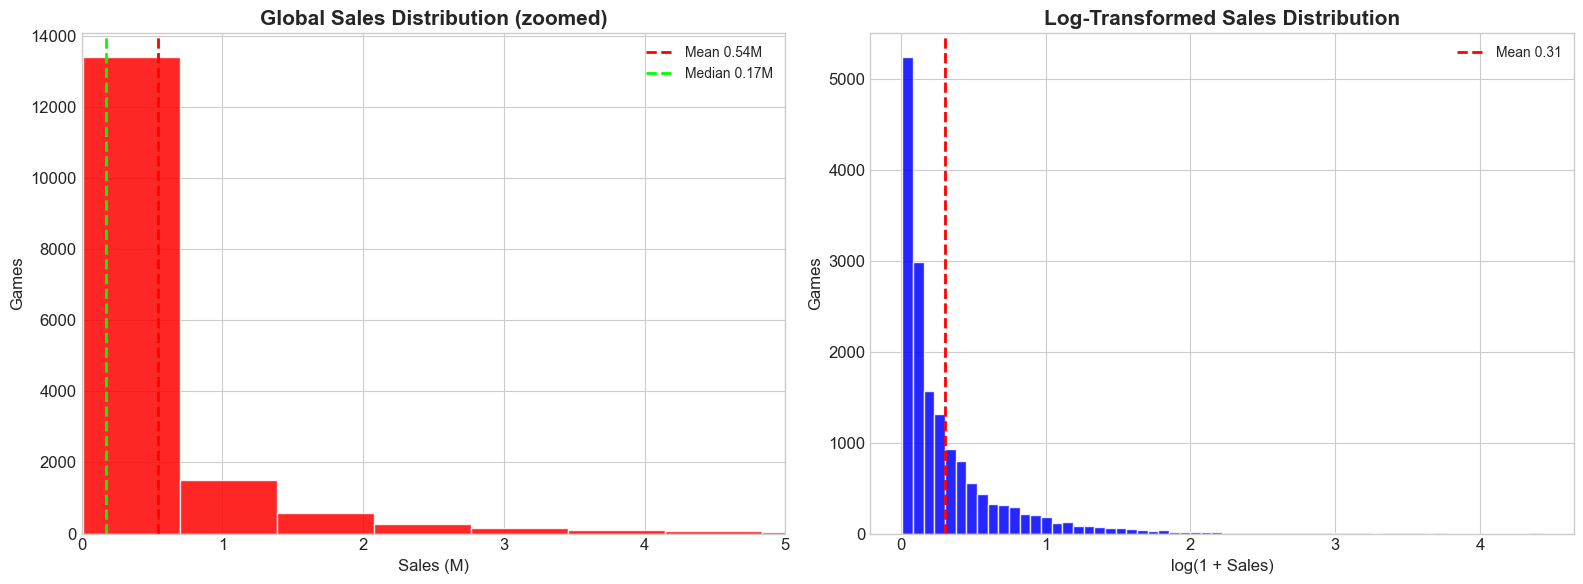

Skewness = 17.30 (heavily right-skewed).  Log-transform makes it more normal.


In [24]:
# ── EDA 1: Target distribution ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw distribution (zoomed to 0-5M)
axes[0].hist(y, bins=120, color=PAL[0], edgecolor='white', alpha=0.85)
axes[0].set_xlim(0, 5)
axes[0].axvline(y.mean(), color='red', ls='--', lw=2, label=f'Mean {y.mean():.2f}M')
axes[0].axvline(np.median(y), color='lime', ls='--', lw=2, label=f'Median {np.median(y):.2f}M')
axes[0].set_title('Global Sales Distribution (zoomed)', fontweight='bold')
axes[0].set_xlabel('Sales (M)'); axes[0].set_ylabel('Games')
axes[0].legend(fontsize=10)

# Log-transformed
y_log = np.log1p(y)
axes[1].hist(y_log, bins=60, color=PAL[1], edgecolor='white', alpha=0.85)
axes[1].axvline(y_log.mean(), color='red', ls='--', lw=2, label=f'Mean {y_log.mean():.2f}')
axes[1].set_title('Log-Transformed Sales Distribution', fontweight='bold')
axes[1].set_xlabel('log(1 + Sales)'); axes[1].set_ylabel('Games')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

sk = pd.Series(y).skew()
print(f'Skewness = {sk:.2f} (heavily right-skewed).  Log-transform makes it more normal.')

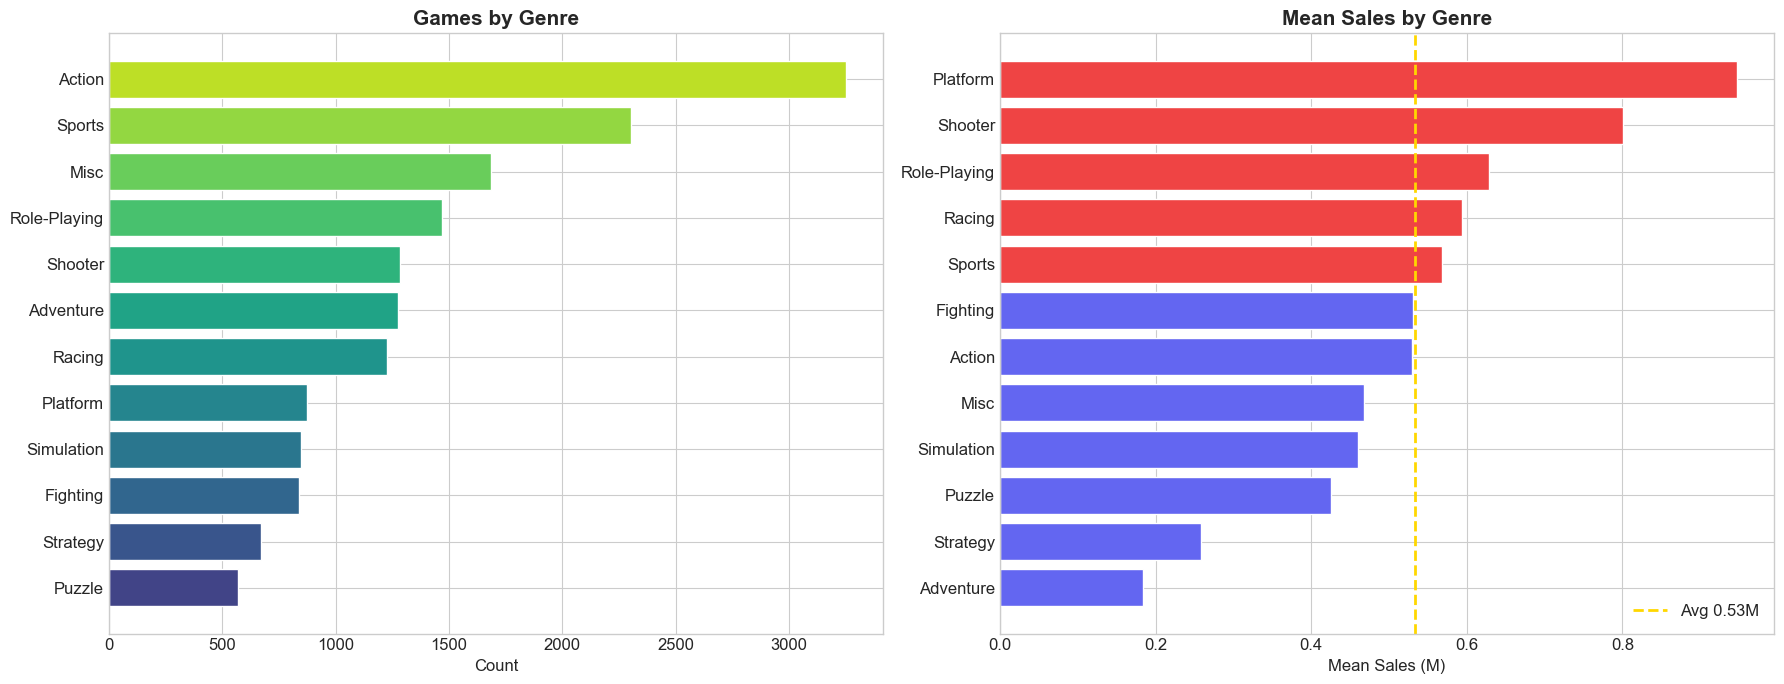

Action has the most titles, but Platform and Shooter have higher average sales.


In [25]:
# ── EDA 2: Genre analysis ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

gc = df['Genre'].value_counts()
axes[0].barh(gc.index[::-1], gc.values[::-1],
             color=plt.cm.viridis(np.linspace(.2,.9,len(gc))), edgecolor='white')
axes[0].set_title('Games by Genre', fontweight='bold')
axes[0].set_xlabel('Count')

ga = df.groupby('Genre')['Global_Sales'].mean().sort_values()
clr = ['#ef4444' if v > ga.mean() else '#6366f1' for v in ga.values]
axes[1].barh(ga.index, ga.values, color=clr, edgecolor='white')
axes[1].axvline(ga.mean(), color='gold', ls='--', lw=2, label=f'Avg {ga.mean():.2f}M')
axes[1].set_title('Mean Sales by Genre', fontweight='bold')
axes[1].set_xlabel('Mean Sales (M)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Action has the most titles, but Platform and Shooter have higher average sales.')

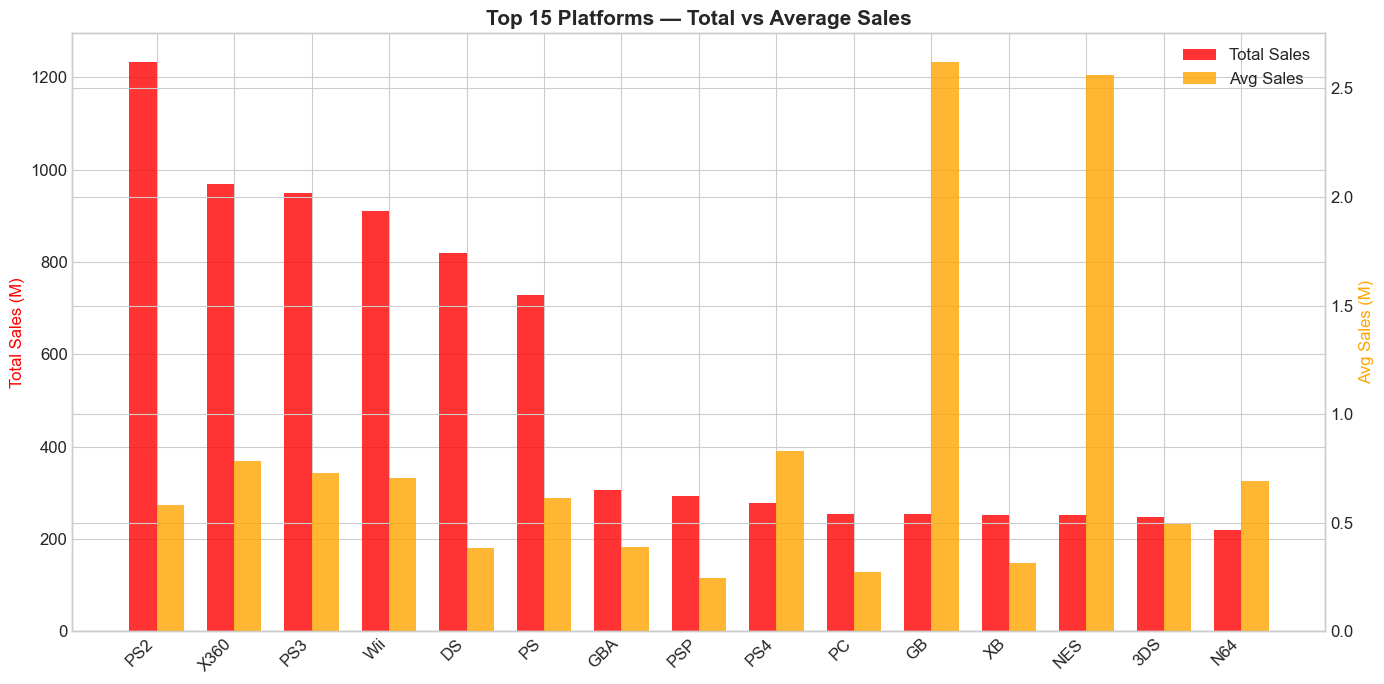

PS2 leads in total sales, but Game Boy has the highest average per game.


In [26]:
# ── EDA 3: Platform analysis (top 15) ───────────────────────────

ps = df.groupby('Platform')['Global_Sales'].agg(['sum','mean','count'])
ps = ps.sort_values('sum', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ps))
w = 0.35
ax.bar(x - w/2, ps['sum'], w, label='Total Sales', color=PAL[0], alpha=0.8)
ax2 = ax.twinx()
ax2.bar(x + w/2, ps['mean'], w, label='Avg Sales', color=PAL[3], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ps.index, rotation=45, ha='right')
ax.set_ylabel('Total Sales (M)', color=PAL[0])
ax2.set_ylabel('Avg Sales (M)', color=PAL[3])
ax.set_title('Top 15 Platforms — Total vs Average Sales', fontweight='bold', fontsize=15)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc='upper right')
plt.tight_layout()
plt.show()

print('PS2 leads in total sales, but Game Boy has the highest average per game.')

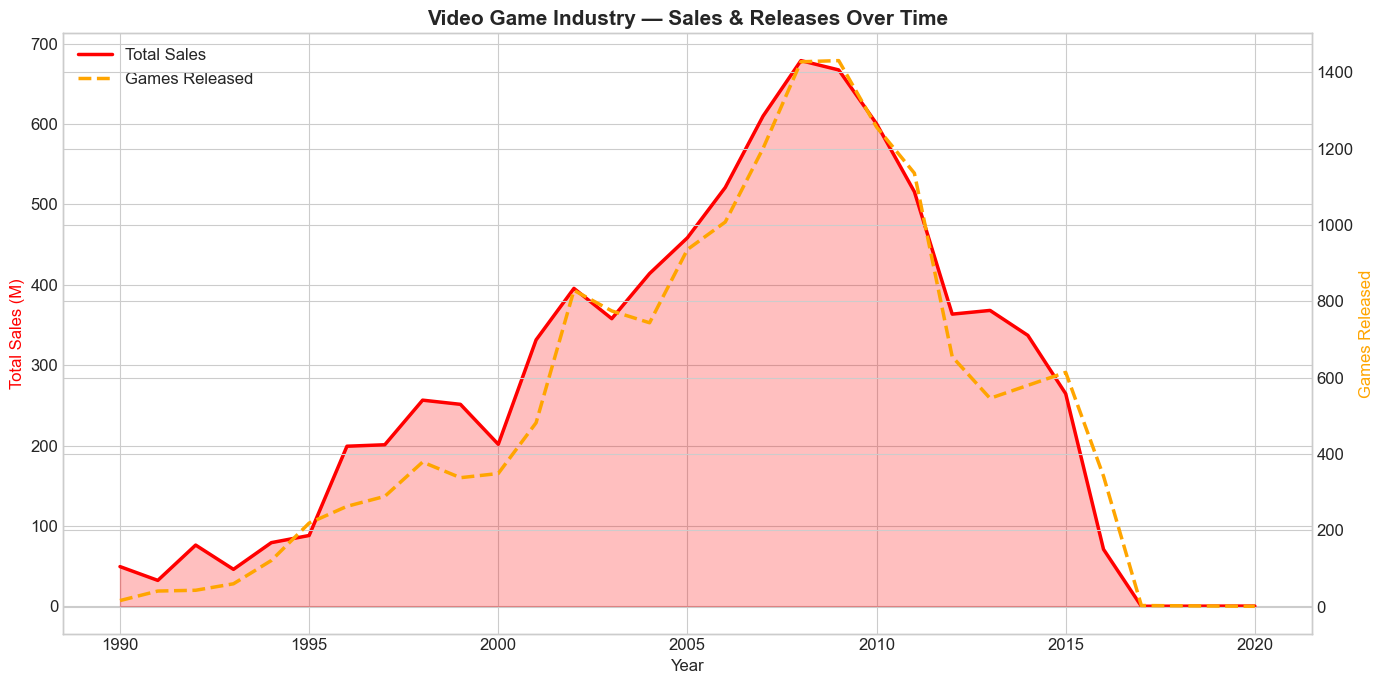

The industry peaked around 2008-2009 during the PS2/Wii/X360 era.


In [27]:
# ── EDA 4: Sales trends over the years ──────────────────────────

yd = df.groupby('Year').agg({'Global_Sales':'sum','Name':'count'}).rename(columns={'Name':'Games'})
yd = yd[(yd.index >= 1990) & (yd.index <= 2020)]

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.fill_between(yd.index, yd['Global_Sales'], alpha=0.25, color=PAL[0])
ax1.plot(yd.index, yd['Global_Sales'], color=PAL[0], lw=2.5, label='Total Sales')
ax1.set_ylabel('Total Sales (M)', color=PAL[0])

ax2 = ax1.twinx()
ax2.plot(yd.index, yd['Games'], color=PAL[3], lw=2.5, ls='--', label='Games Released')
ax2.set_ylabel('Games Released', color=PAL[3])

ax1.set_xlabel('Year')
ax1.set_title('Video Game Industry — Sales & Releases Over Time', fontweight='bold', fontsize=15)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')
plt.tight_layout()
plt.show()

print('The industry peaked around 2008-2009 during the PS2/Wii/X360 era.')

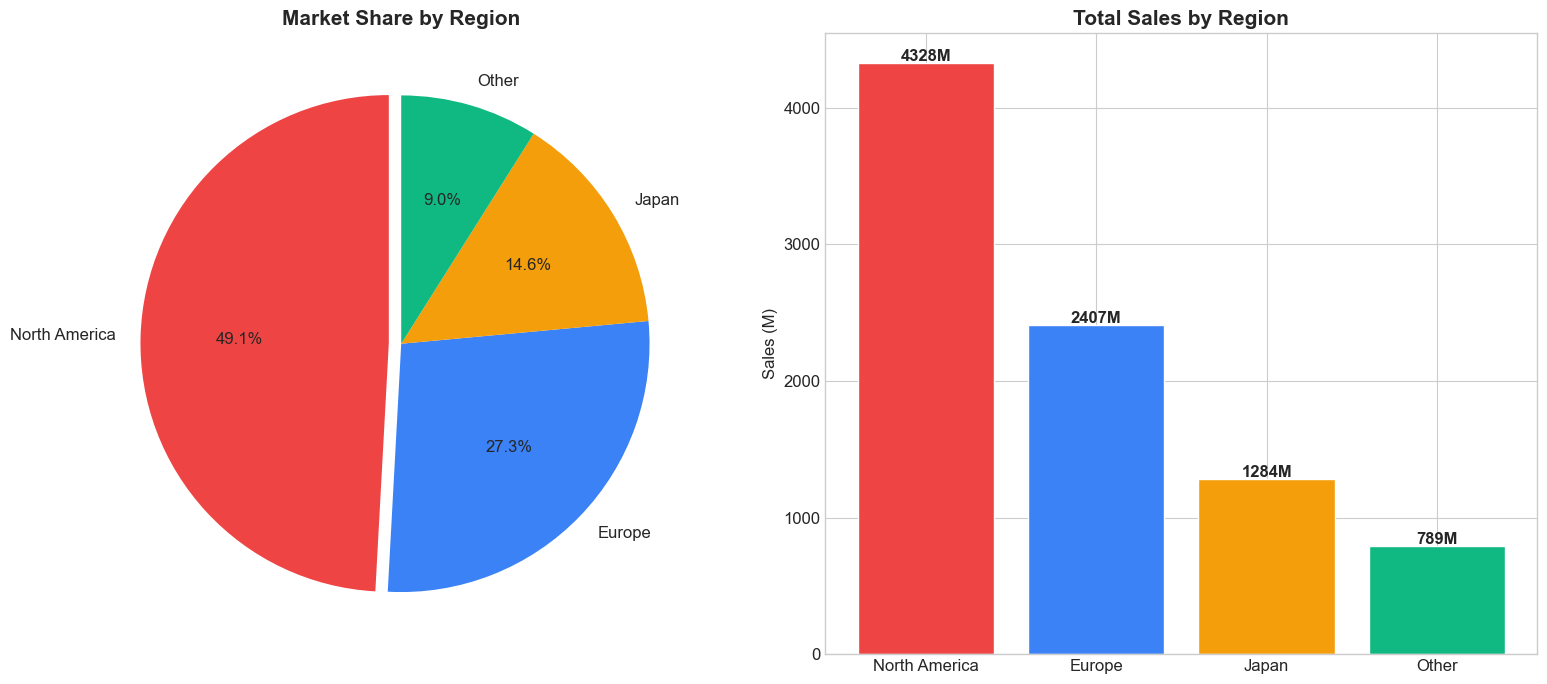

North America dominates with ~50% of the market, followed by Europe at ~27%.


In [28]:
# ── EDA 5: Regional sales comparison ────────────────────────────

regions = {'North America':'NA_Sales','Europe':'EU_Sales','Japan':'JP_Sales','Other':'Other_Sales'}
totals = {k: df[v].sum() for k, v in regions.items()}
rc = ['#ef4444','#3b82f6','#f59e0b','#10b981']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].pie(totals.values(), labels=totals.keys(), autopct='%1.1f%%',
            colors=rc, startangle=90, explode=[.05,0,0,0],
            textprops={'fontsize': 12})
axes[0].set_title('Market Share by Region', fontweight='bold')

axes[1].bar(totals.keys(), totals.values(), color=rc, edgecolor='white')
for i, v in enumerate(totals.values()):
    axes[1].text(i, v + 15, f'{v:.0f}M', ha='center', fontweight='bold')
axes[1].set_title('Total Sales by Region', fontweight='bold')
axes[1].set_ylabel('Sales (M)')

plt.tight_layout()
plt.show()

print('North America dominates with ~50% of the market, followed by Europe at ~27%.')

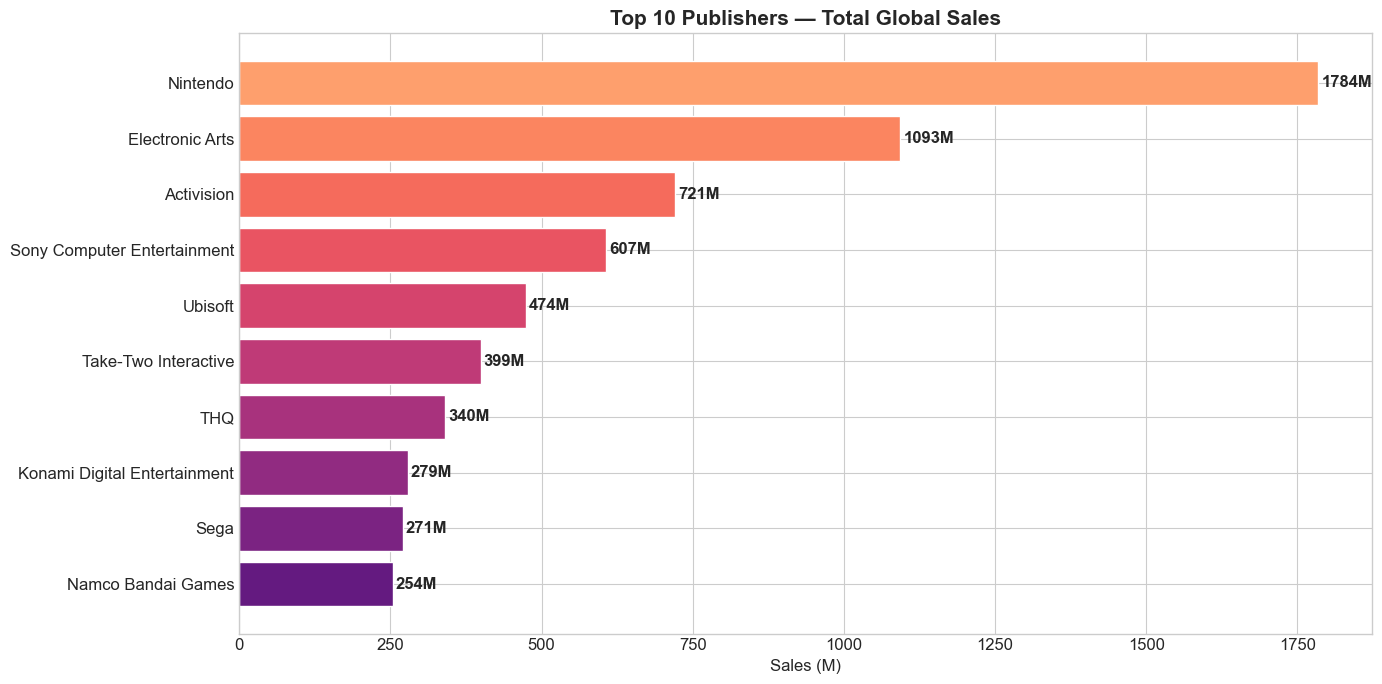

Nintendo leads by a huge margin, showing the power of strong franchises.


In [29]:
# ── EDA 6: Publisher analysis (top 10) ──────────────────────────

tp = df.groupby('Publisher')['Global_Sales'].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(tp.index, tp.values,
               color=plt.cm.magma(np.linspace(.3,.8,10)), edgecolor='white')
for bar, val in zip(bars, tp.values):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2.,
            f'{val:.0f}M', va='center', fontweight='bold')
ax.set_title('Top 10 Publishers — Total Global Sales', fontweight='bold', fontsize=15)
ax.set_xlabel('Sales (M)')
plt.tight_layout()
plt.show()

print('Nintendo leads by a huge margin, showing the power of strong franchises.')

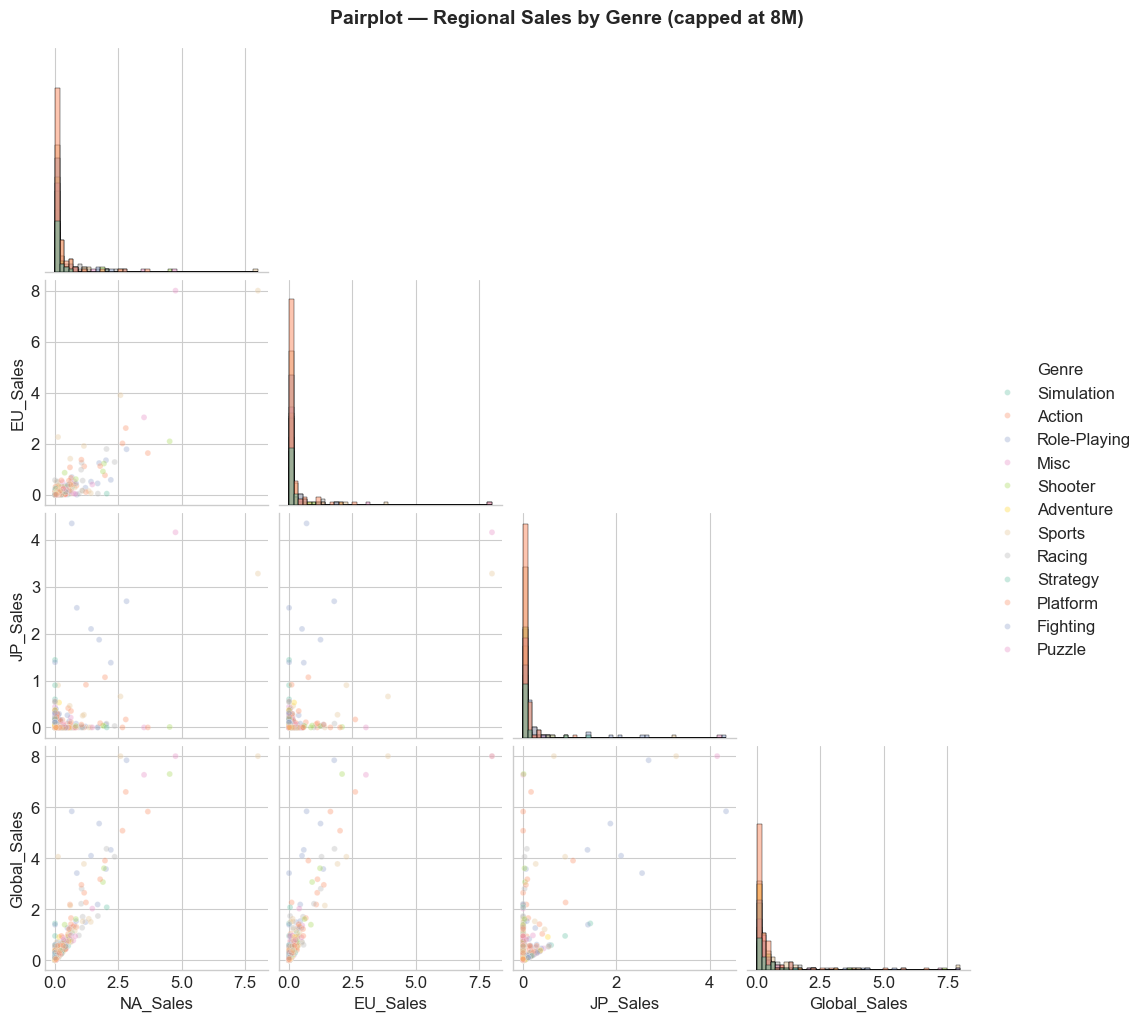

NA_Sales shows the strongest visual correlation with Global_Sales.


In [30]:
# ── EDA 7: Pairplot of sales columns ────────────────────────────

sample = df[['NA_Sales','EU_Sales','JP_Sales','Global_Sales','Genre']].sample(
    min(500, len(df)), random_state=42)
for c in ['NA_Sales','EU_Sales','JP_Sales','Global_Sales']:
    sample[c] = sample[c].clip(upper=8)

g = sns.pairplot(sample, hue='Genre', diag_kind='hist', palette='Set2',
                 plot_kws={'alpha': 0.35, 's': 18}, corner=True)
g.figure.suptitle('Pairplot — Regional Sales by Genre (capped at 8M)', y=1.02,
                   fontsize=14, fontweight='bold')
plt.show()

print('NA_Sales shows the strongest visual correlation with Global_Sales.')

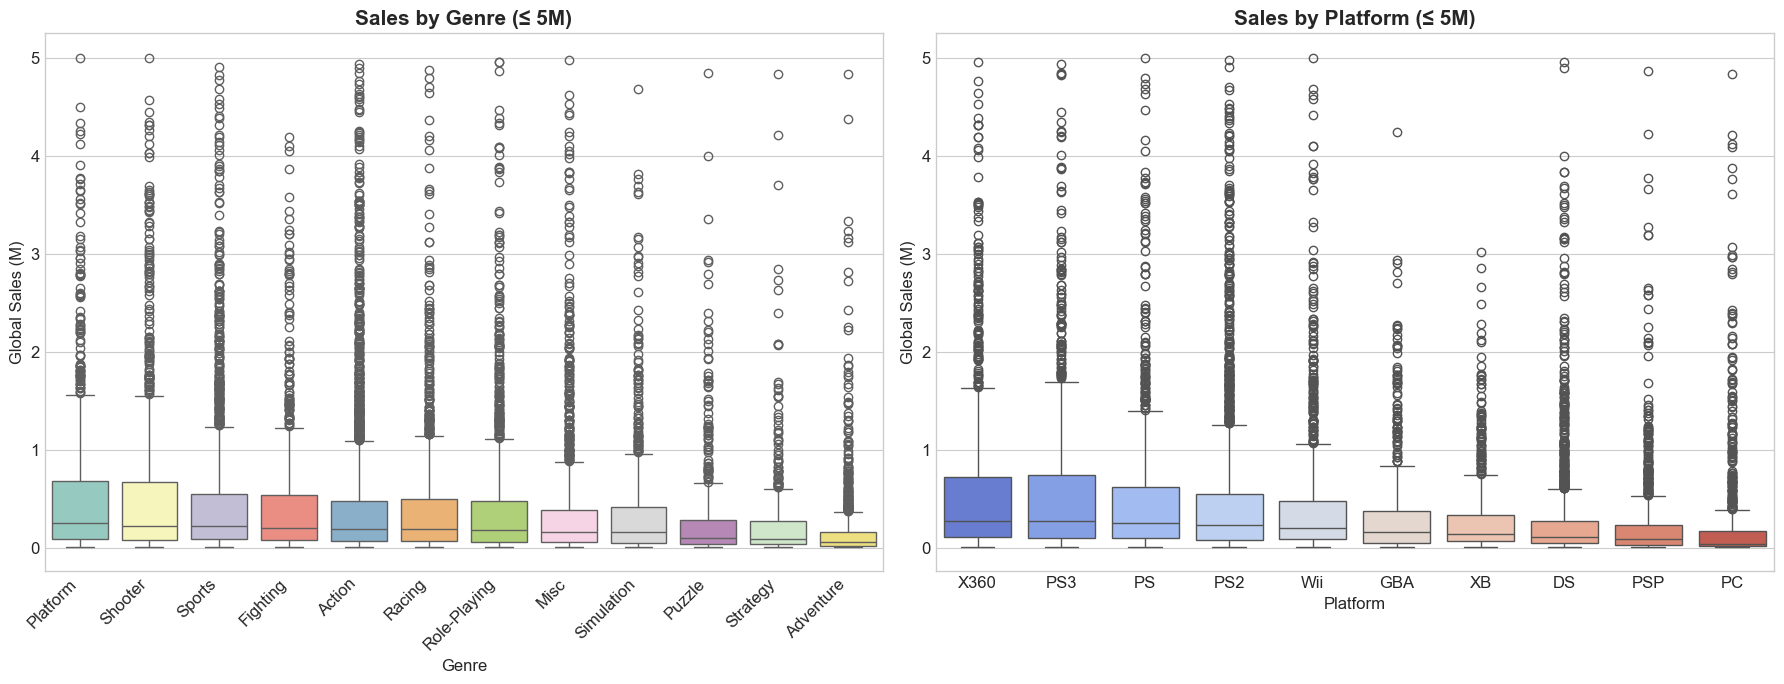

Platform and Shooter genres have the highest median sales among common genres.


In [31]:
# ── EDA 8: Boxplots by category ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_cap = df[df['Global_Sales'] <= 5]
go = df_cap.groupby('Genre')['Global_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df_cap, x='Genre', y='Global_Sales', order=go, palette='Set3', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Sales by Genre (≤ 5M)', fontweight='bold')
axes[0].set_ylabel('Global Sales (M)')

tp2 = df['Platform'].value_counts().head(10).index
df_pl = df_cap[df_cap['Platform'].isin(tp2)]
po = df_pl.groupby('Platform')['Global_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df_pl, x='Platform', y='Global_Sales', order=po, palette='coolwarm', ax=axes[1])
axes[1].set_title('Sales by Platform (≤ 5M)', fontweight='bold')
axes[1].set_ylabel('Global Sales (M)')

plt.tight_layout()
plt.show()

print('Platform and Shooter genres have the highest median sales among common genres.')

---

## 6. Feature Engineering

We create new features from the existing data to give our models more predictive power.

In [32]:
# ────────────────────────────────────────────
# Feature engineering
# ────────────────────────────────────────────

df_fe = df[df['Global_Sales'] > 0].copy()

# 1  Decade — groups years into decades
df_fe['Decade'] = (df_fe['Year'] // 10) * 10

# 2  Is_Top_Publisher — binary flag for top-10 publishers by total revenue
top10_pub = df_fe.groupby('Publisher')['Global_Sales'].sum().nlargest(10).index
df_fe['Is_Top_Publisher'] = df_fe['Publisher'].isin(top10_pub).astype(int)

# 3  Platform_Age — how many years since the platform was first seen
launch = df_fe.groupby('Platform')['Year'].min().to_dict()
df_fe['Platform_Age'] = df_fe.apply(lambda r: r['Year'] - launch.get(r['Platform'], r['Year']), axis=1)

# 4  Genre_Frequency — how common this genre is (proportion)
gf = df_fe['Genre'].value_counts(normalize=True).to_dict()
df_fe['Genre_Frequency'] = df_fe['Genre'].map(gf)

# 5  Log_Global_Sales — log-transformed target (for alternative modelling)
df_fe['Log_Global_Sales'] = np.log1p(df_fe['Global_Sales'])

print('5 new features created:')
print('   1. Decade            — Groups release years into decades')
print('   2. Is_Top_Publisher  — 1 if publisher is in the top-10 by revenue')
print('   3. Platform_Age      — Years since the platform first appeared')
print('   4. Genre_Frequency   — Proportion of games in this genre')
print('   5. Log_Global_Sales  — Log-transformed target (helper column)')

df_fe[['Name','Platform','Year','Decade','Is_Top_Publisher',
        'Platform_Age','Genre_Frequency','Global_Sales']].head(10)

5 new features created:
   1. Decade            — Groups release years into decades
   2. Is_Top_Publisher  — 1 if publisher is in the top-10 by revenue
   3. Platform_Age      — Years since the platform first appeared
   4. Genre_Frequency   — Proportion of games in this genre
   5. Log_Global_Sales  — Log-transformed target (helper column)


,Name,Platform,Year,Decade,Is_Top_Publisher,Platform_Age,Genre_Frequency,Global_Sales
0,Wii Sports,Wii,2006,2000,1,0,0.1414,82.7400
1,Super Mario Bros.,NES,1985,1980,1,2,0.0537,40.2400
2,Mario Kart Wii,Wii,2008,2000,1,2,0.0752,35.8200
3,Wii Sports Resort,Wii,2009,2000,1,3,0.1414,33.0000
4,Pokemon Red/Pokemon Blue,GB,1996,1990,1,8,0.0902,31.3700
5,Tetris,GB,1989,1980,1,1,0.0350,30.2600
6,New Super Mario Bros.,DS,2006,2000,1,21,0.0537,30.0100
7,Wii Play,Wii,2006,2000,1,0,0.1035,29.0200
8,New Super Mario Bros. Wii,Wii,2009,2000,1,3,0.0537,28.6200
9,Duck Hunt,NES,1984,1980,1,1,0.0787,28.3100


In [33]:
# ────────────────────────────────────────────
# Prepare enhanced feature matrix
# ────────────────────────────────────────────

FEAT_ENH = ['Platform_enc','Genre_enc','Publisher_enc','Year',
            'Decade','Is_Top_Publisher','Platform_Age','Genre_Frequency']

X_enh = df_fe[FEAT_ENH].values
y_enh = df_fe['Global_Sales'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_enh, y_enh, test_size=0.20, random_state=42)

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

print(f'Enhanced features: {FEAT_ENH}')
print(f'    Train {X_tr.shape[0]:,}  |  Test {X_te.shape[0]:,}  |  Features {X_tr.shape[1]}')

Enhanced features: ['Platform_enc', 'Genre_enc', 'Publisher_enc', 'Year', 'Decade', 'Is_Top_Publisher', 'Platform_Age', 'Genre_Frequency']
    Train 13,032  |  Test 3,259  |  Features 8


---

## 7. Machine Learning — Regression Models

We train **6 different regression models** and compare them side-by-side.

**Target variable:** `Global_Sales` — the total worldwide sales of a video game in millions of units.

**Why this target?** Global sales is the single most important business metric. It measures the total commercial success of a game across all markets.

| # | Model | Type |
|---|-------|------|
| 1 | Linear Regression | Linear |
| 2 | Decision Tree Regressor | Tree-based |
| 3 | Random Forest Regressor | Ensemble |
| 4 | Gradient Boosting Regressor | Ensemble |
| 5 | Extra Trees Regressor | Ensemble  |
| 6 | XGBoost Regressor | Ensemble |

In [35]:
# ────────────────────────────────────────────
# Define all models
# ────────────────────────────────────────────

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42, max_depth=15),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Extra Trees':       ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

if HAS_XGBOOST:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42,
                                     learning_rate=0.1, max_depth=6, verbosity=0)

print(f'Models to train: {len(models)}')
for m in models:
    print(f'   • {m}')

Models to train: 6
   • Linear Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • Extra Trees
   • XGBoost


In [36]:
# ────────────────────────────────────────────
# Train all models and collect metrics
# ────────────────────────────────────────────

results     = {}      # metrics dict per model
preds       = {}      # y_pred per model
fitted      = {}      # trained model objects

print('Training all models with enhanced features …')
print('=' * 60)

for name, mdl in models.items():
    mdl.fit(X_tr_sc, y_tr)
    fitted[name] = mdl

    yp = mdl.predict(X_te_sc)
    preds[name] = yp

    mae_  = mean_absolute_error(y_te, yp)
    mse_  = mean_squared_error(y_te, yp)
    rmse_ = np.sqrt(mse_)
    r2_   = r2_score(y_te, yp)

    cv = cross_val_score(mdl, X_tr_sc, y_tr, cv=5, scoring='r2', n_jobs=-1)

    results[name] = {
        'MAE': mae_, 'MSE': mse_, 'RMSE': rmse_,
        'R²': r2_,
        'CV R² Mean': cv.mean(),
        'CV R² Std':  cv.std()
    }

    print(f'\n   {name}')
    print(f'     R² = {r2_:.4f}   RMSE = {rmse_:.4f}   MAE = {mae_:.4f}')
    print(f'     CV R² = {cv.mean():.4f} ± {cv.std():.4f}')

print(f'\n\n All {len(models)} models trained!')

Training all models with enhanced features …

   Linear Regression
     R² = 0.0164   RMSE = 2.0513   MAE = 0.5911
     CV R² = 0.0326 ± 0.0055

   Decision Tree
     R² = -0.1124   RMSE = 2.1814   MAE = 0.5867
     CV R² = -0.4722 ± 0.2424

   Random Forest
     R² = 0.0627   RMSE = 2.0025   MAE = 0.5478
     CV R² = -0.0242 ± 0.0726

   Gradient Boosting
     R² = 0.0721   RMSE = 1.9924   MAE = 0.5427
     CV R² = 0.1267 ± 0.0185

   Extra Trees
     R² = -0.0455   RMSE = 2.1148   MAE = 0.5757
     CV R² = -0.1887 ± 0.1064

   XGBoost
     R² = 0.0577   RMSE = 2.0078   MAE = 0.5288
     CV R² = 0.1305 ± 0.0558


 All 6 models trained!


---

## 8. Model Evaluation

We evaluate every model using professional metrics and rich visualizations.

In [37]:
# ────────────────────────────────────────────
# 8A — Comparison table
# ────────────────────────────────────────────

rdf = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print('MODEL COMPARISON TABLE (sorted by R²)')
print('=' * 75)
display(rdf.round(4))

best_name = rdf.index[0]
best_r2   = rdf.loc[best_name, 'R²']
print(f'\nBest model: {best_name}  (R² = {best_r2:.4f})')

MODEL COMPARISON TABLE (sorted by R²)


,MAE,MSE,RMSE,R²,CV R² Mean,CV R² Std
Gradient Boosting,0.5427,3.9696,1.9924,0.0721,0.1267,0.0185
Random Forest,0.5478,4.0099,2.0025,0.0627,-0.0242,0.0726
XGBoost,0.5288,4.0311,2.0078,0.0577,0.1305,0.0558
Linear Regression,0.5911,4.2078,2.0513,0.0164,0.0326,0.0055
Extra Trees,0.5757,4.4725,2.1148,-0.0455,-0.1887,0.1064
Decision Tree,0.5867,4.7586,2.1814,-0.1124,-0.4722,0.2424



Best model: Gradient Boosting  (R² = 0.0721)


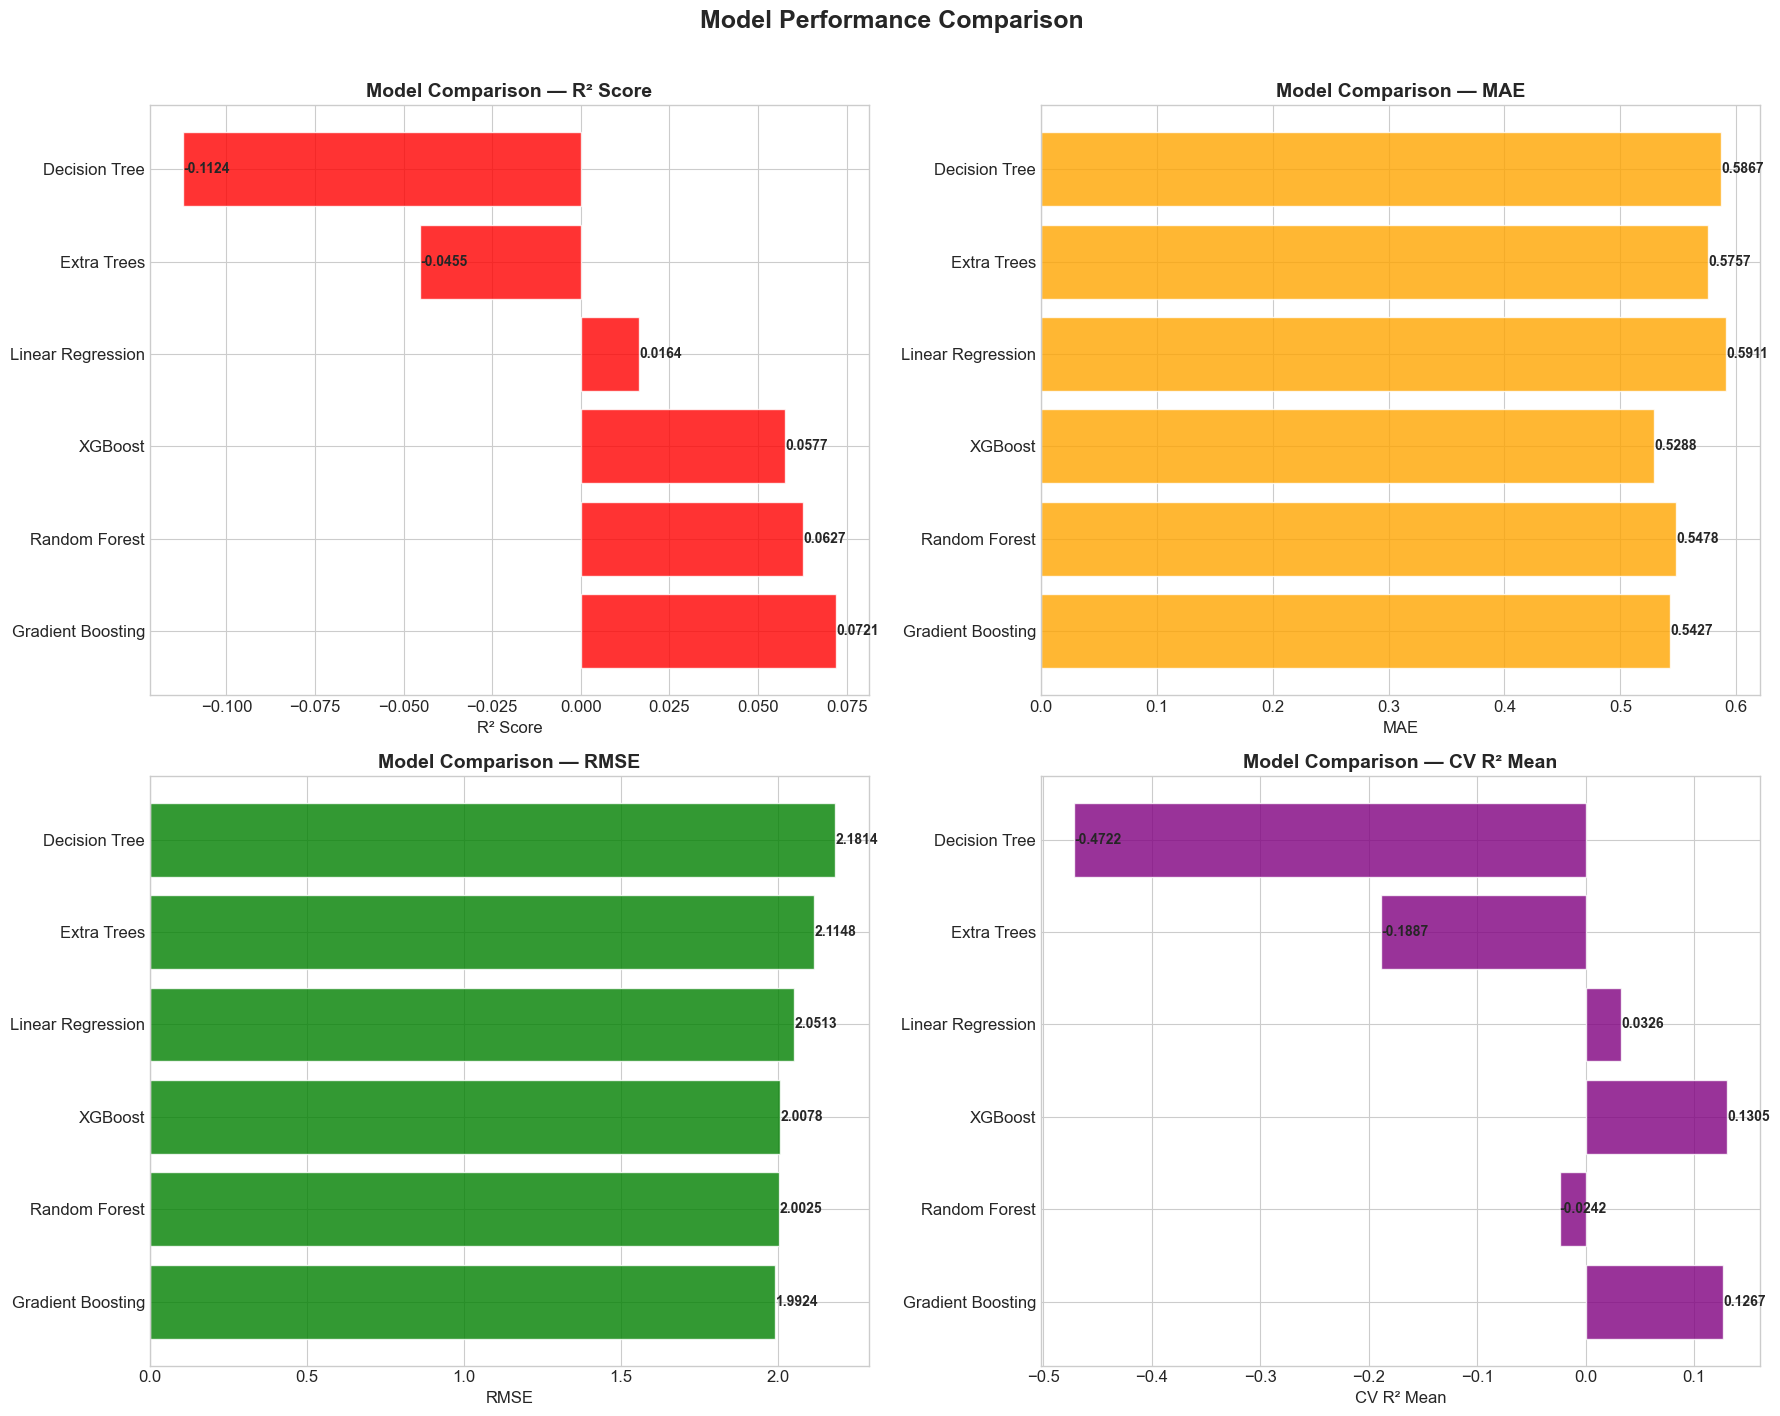

In [38]:
# ────────────────────────────────────────────
# 8B — Model comparison bar charts
# ────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
metrics_vis = [('R²','R² Score',PAL[0]), ('MAE','MAE',PAL[3]),
              ('RMSE','RMSE',PAL[2]), ('CV R² Mean','CV R² Mean',PAL[4])]

for idx, (metric, title, color) in enumerate(metrics_vis):
    ax = axes[idx // 2][idx % 2]
    vals = rdf[metric].values
    names = rdf.index
    ax.barh(names, vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Model Comparison — {title}', fontweight='bold', fontsize=14)
    ax.set_xlabel(title)
    for bar, v in zip(ax.patches, vals):
        ax.text(v + 0.001 * max(abs(v), 0.01), bar.get_y() + bar.get_height() / 2.,
                f'{v:.4f}', va='center', fontweight='bold', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

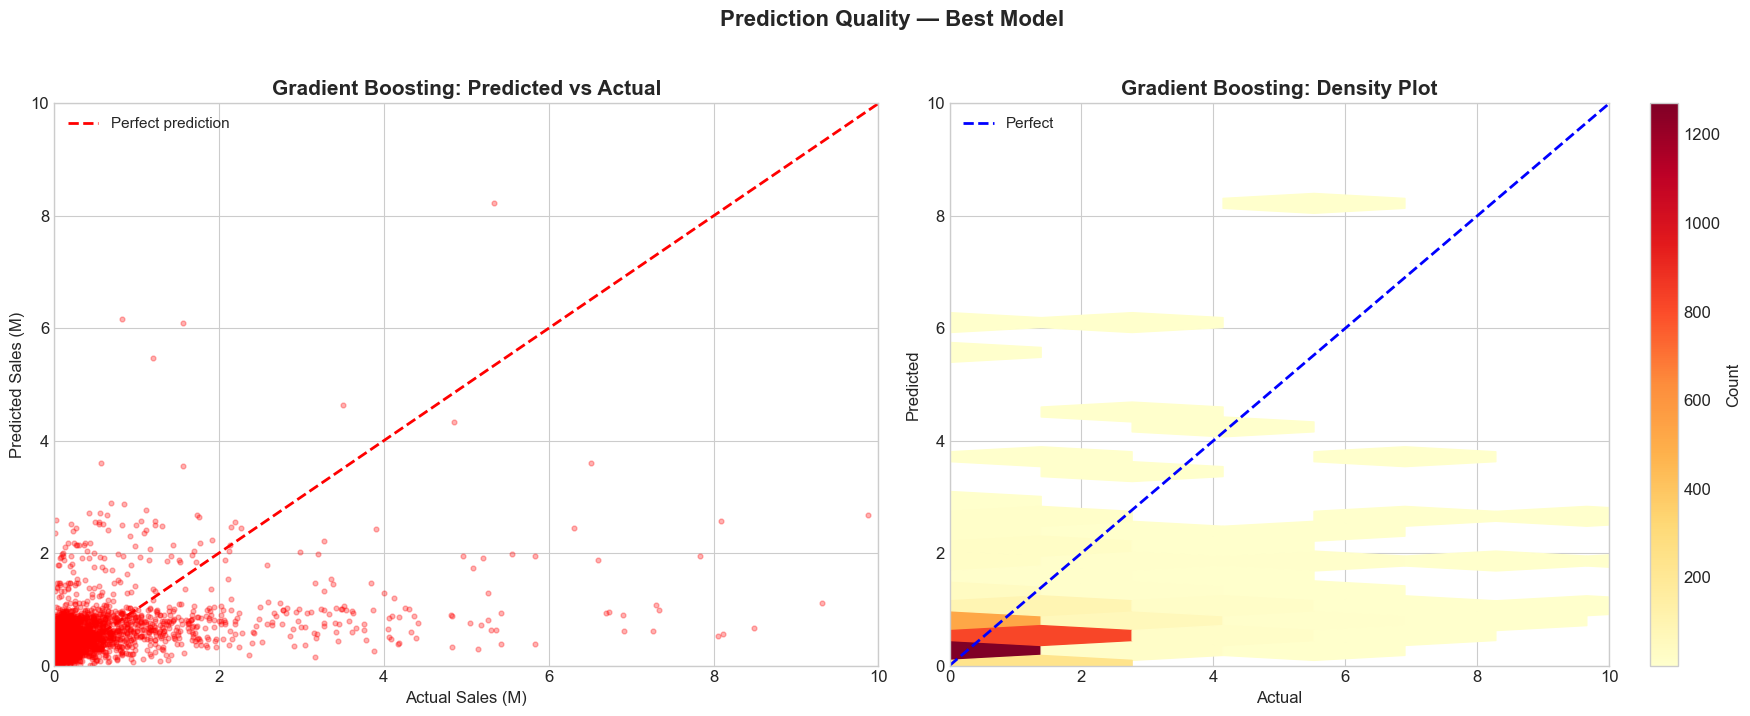

Points near the red dashed line are accurate predictions.
The model handles average games well but struggles with blockbusters.


In [40]:
# ────────────────────────────────────────────
# 8C — Predicted vs Actual (best model)
# ────────────────────────────────────────────

best_pred = preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter
axes[0].scatter(y_te, best_pred, alpha=0.3, s=12, color=PAL[0])
lim = min(max(y_te.max(), best_pred.max()), 10)
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlim(0, 10); axes[0].set_ylim(0, 10)
axes[0].set_xlabel('Actual Sales (M)'); axes[0].set_ylabel('Predicted Sales (M)')
axes[0].set_title(f'{best_name}: Predicted vs Actual', fontweight='bold')
axes[0].legend(fontsize=11)

# Hexbin density
hb = axes[1].hexbin(y_te, best_pred, gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].plot([0, lim], [0, lim], 'b--', lw=2, label='Perfect')
axes[1].set_xlim(0, 10); axes[1].set_ylim(0, 10)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'{best_name}: Density Plot', fontweight='bold')
axes[1].legend(fontsize=11)
plt.colorbar(hb, ax=axes[1], label='Count')

plt.suptitle('Prediction Quality — Best Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Points near the red dashed line are accurate predictions.')
print('The model handles average games well but struggles with blockbusters.')

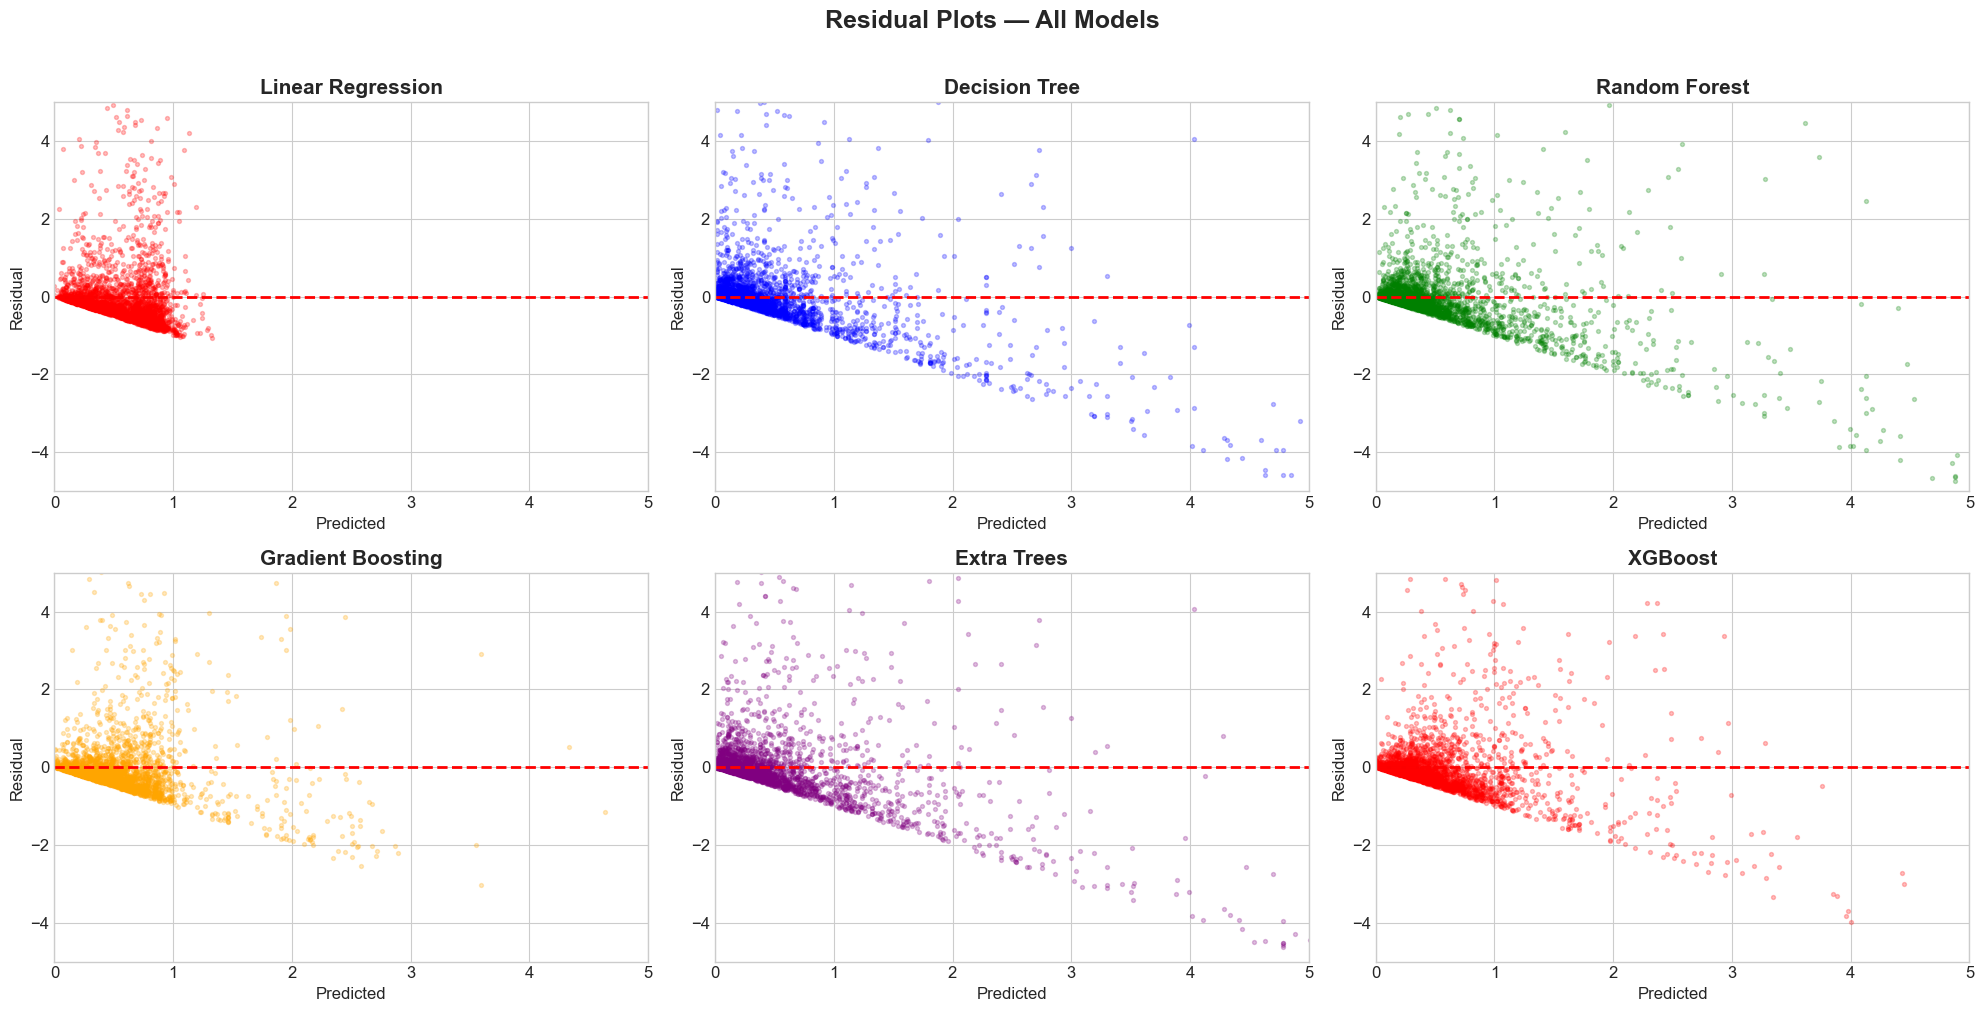

Residuals scattered randomly around 0 = good.  Patterns = model is missing something.


In [41]:
# ────────────────────────────────────────────
# 8D — Residual plots (all models)
# ────────────────────────────────────────────

n_mod = len(preds)
ncols = 3
nrows = (n_mod + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, (name, yp) in enumerate(preds.items()):
    resid = y_te - yp
    axes[i].scatter(yp, resid, alpha=0.25, s=8, color=PAL[i % len(PAL)])
    axes[i].axhline(0, color='red', ls='--', lw=2)
    axes[i].set_xlim(0, 5); axes[i].set_ylim(-5, 5)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Residual')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Residual Plots — All Models', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Residuals scattered randomly around 0 = good.  Patterns = model is missing something.')

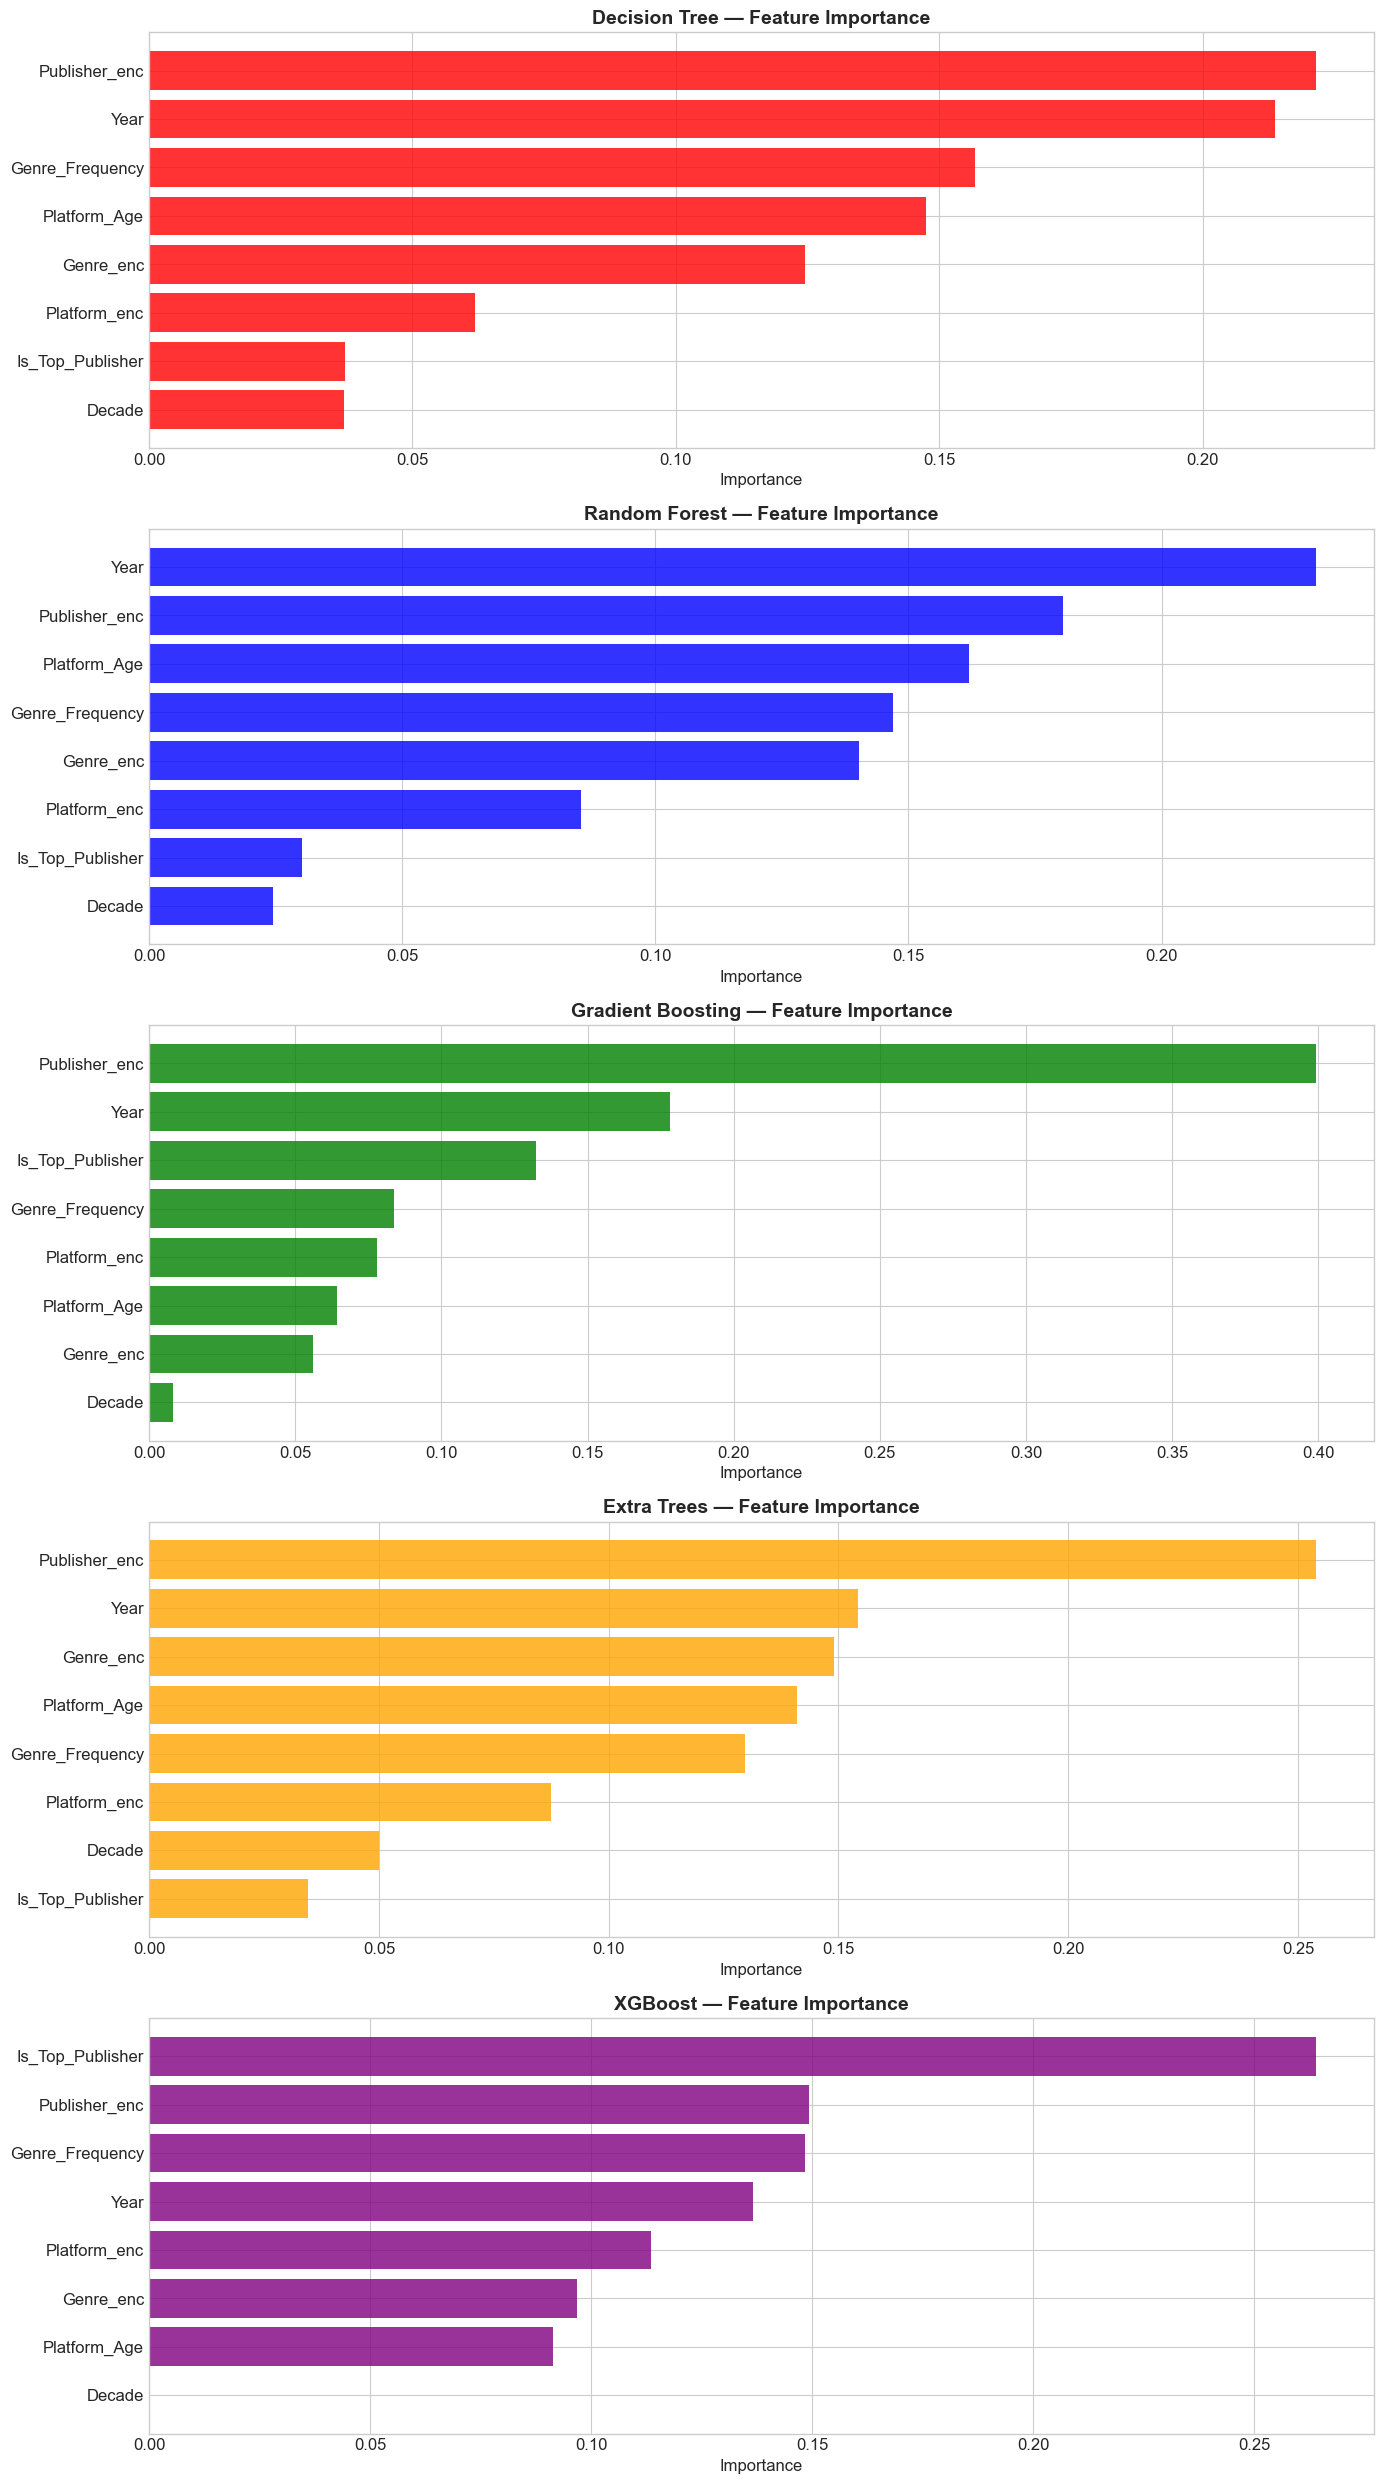

Publisher, Platform, and Genre are usually the strongest predictors.


In [42]:
# ────────────────────────────────────────────
# 8E — Feature importance (tree-based models)
# ────────────────────────────────────────────

tree_mods = {n: m for n, m in fitted.items() if hasattr(m, 'feature_importances_')}
feat_names = FEAT_ENH

n_tree = len(tree_mods)
fig, axes = plt.subplots(n_tree, 1, figsize=(14, 5 * n_tree))
if n_tree == 1:
    axes = [axes]

for i, (name, mdl) in enumerate(tree_mods.items()):
    imp = mdl.feature_importances_
    si = np.argsort(imp)
    axes[i].barh([feat_names[j] for j in si], imp[si],
                 color=PAL[i % len(PAL)], alpha=0.8)
    axes[i].set_title(f'{name} — Feature Importance', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('Publisher, Platform, and Genre are usually the strongest predictors.')

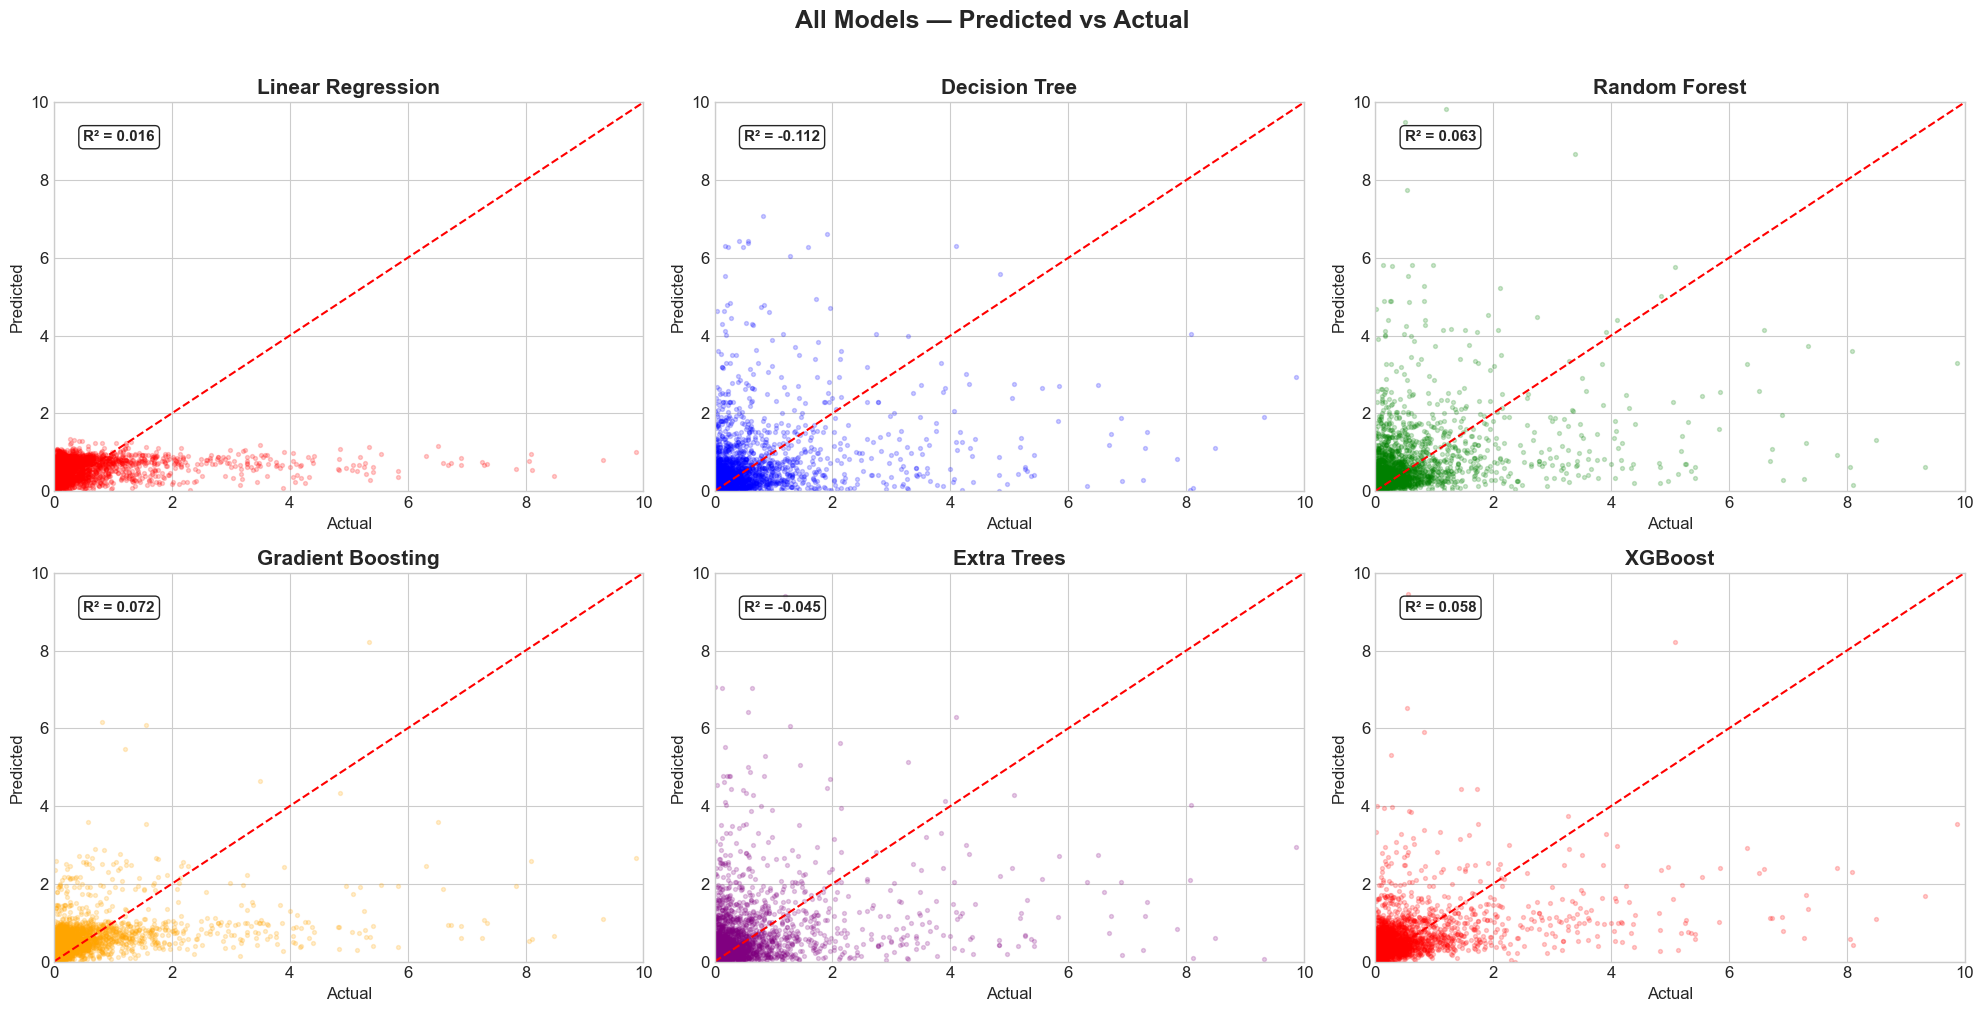

In [43]:
# ────────────────────────────────────────────
# 8F — All models: Predicted vs Actual (grid)
# ────────────────────────────────────────────

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, (name, yp) in enumerate(preds.items()):
    axes[i].scatter(y_te, yp, alpha=0.2, s=8, color=PAL[i % len(PAL)])
    axes[i].plot([0, 10], [0, 10], 'r--', lw=1.5)
    axes[i].set_xlim(0, 10); axes[i].set_ylim(0, 10)
    r2 = r2_score(y_te, yp)
    axes[i].text(0.5, 9, f'R² = {r2:.3f}', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Actual'); axes[i].set_ylabel('Predicted')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('All Models — Predicted vs Actual', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 9. Hyperparameter Tuning

We apply **RandomizedSearchCV** on the Gradient Boosting model to find better hyperparameters.

In [44]:
# ────────────────────────────────────────────
# RandomizedSearchCV — Gradient Boosting
# ────────────────────────────────────────────

print('Hyperparameter Tuning — Gradient Boosting')
print('=' * 60)

param_dist = {
    'n_estimators':    [50, 100, 200, 300],
    'max_depth':       [3, 5, 7, 10, 15],
    'learning_rate':   [0.01, 0.05, 0.1, 0.15, 0.2],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'subsample':       [0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_tr_sc, y_tr)

print(f'\nBest CV R²:  {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Hyperparameter Tuning — Gradient Boosting
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV R²:  0.1378
Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'learning_rate': 0.01}


In [45]:
# ────────────────────────────────────────────
# Evaluate the tuned model
# ────────────────────────────────────────────

tuned = search.best_estimator_
y_tuned = tuned.predict(X_te_sc)

t_mae  = mean_absolute_error(y_te, y_tuned)
t_rmse = np.sqrt(mean_squared_error(y_te, y_tuned))
t_r2   = r2_score(y_te, y_tuned)

default_gb = results.get('Gradient Boosting', {})

comp = pd.DataFrame({
    'Default GB': [default_gb.get('MAE',0), default_gb.get('RMSE',0), default_gb.get('R²',0)],
    'Tuned GB':   [t_mae, t_rmse, t_r2]
}, index=['MAE','RMSE','R²'])

print('Default vs Tuned Gradient Boosting')
print('=' * 50)
display(comp.round(4))

delta = t_r2 - default_gb.get('R²', 0)
print(f'\nR² change: {delta:+.4f}')

Default vs Tuned Gradient Boosting


,Default GB,Tuned GB
MAE,0.5427,0.5325
RMSE,1.9924,1.9935
R²,0.0721,0.0711



R² change: -0.0010


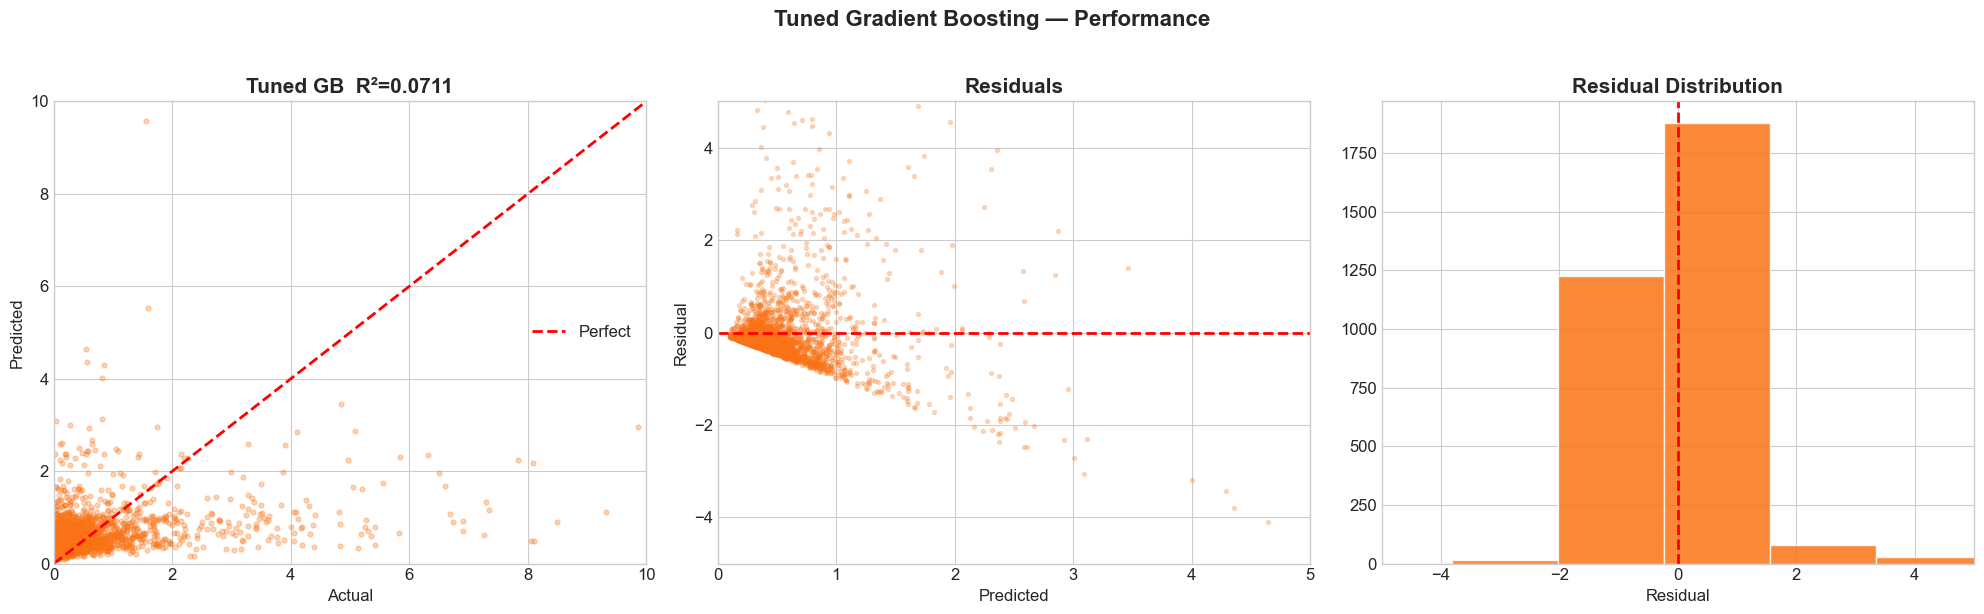

In [46]:
# ────────────────────────────────────────────
# Tuned model visualisations
# ────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1  Predicted vs Actual
axes[0].scatter(y_te, y_tuned, alpha=0.3, s=12, color='#f97316')
axes[0].plot([0,10],[0,10],'r--', lw=2, label='Perfect')
axes[0].set_xlim(0,10); axes[0].set_ylim(0,10)
axes[0].set_title(f'Tuned GB  R²={t_r2:.4f}', fontweight='bold')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].legend()

# 2  Residuals
resid_t = y_te - y_tuned
axes[1].scatter(y_tuned, resid_t, alpha=0.25, s=8, color='#f97316')
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_xlim(0,5); axes[1].set_ylim(-5,5)
axes[1].set_title('Residuals', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')

# 3  Residual distribution
axes[2].hist(resid_t, bins=50, color='#f97316', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', ls='--', lw=2)
axes[2].set_xlim(-5,5)
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual')

plt.suptitle('Tuned Gradient Boosting — Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

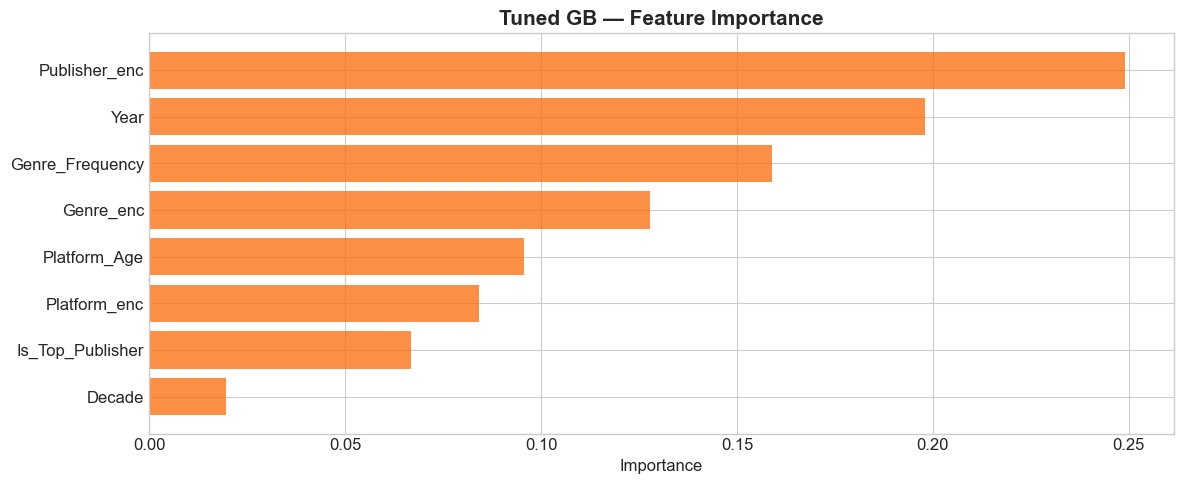

This shows which features the tuned model relies on most heavily.


In [47]:
# ── Tuned feature importance ──

imp_t = tuned.feature_importances_
si = np.argsort(imp_t)
plt.figure(figsize=(12, 5))
plt.barh([FEAT_ENH[j] for j in si], imp_t[si], color='#f97316', alpha=0.8)
plt.title('Tuned GB — Feature Importance', fontweight='bold', fontsize=15)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('This shows which features the tuned model relies on most heavily.')

---

## 10. Final Insights & Conclusion

In [48]:
# ────────────────────────────────────────────
# Final leaderboard
# ────────────────────────────────────────────

final = rdf.copy()
final.loc['Tuned GB'] = [t_mae, np.sqrt(mean_squared_error(y_te, y_tuned)),
                         mean_squared_error(y_te, y_tuned), t_r2,
                         search.best_score_, '-']
final = final.sort_values('R²', ascending=False)
final.insert(0, 'Rank', range(1, len(final) + 1))

print('=' * 70)
print('FINAL MODEL LEADERBOARD')
print('=' * 70)
display(final[['Rank','MAE','RMSE','R²','CV R² Mean']].round(4))
print(f'\nOVERALL WINNER: {final.index[0]}  (R² = {final.iloc[0]["R²"]:.4f})')

FINAL MODEL LEADERBOARD


,Rank,MAE,RMSE,R²,CV R² Mean
Gradient Boosting,1,0.5427,1.9924,0.0721,0.1267
Tuned GB,2,0.5325,3.9739,0.0711,0.1378
Random Forest,3,0.5478,2.0025,0.0627,-0.0242
XGBoost,4,0.5288,2.0078,0.0577,0.1305
Linear Regression,5,0.5911,2.0513,0.0164,0.0326
Extra Trees,6,0.5757,2.1148,-0.0455,-0.1887
Decision Tree,7,0.5867,2.1814,-0.1124,-0.4722



OVERALL WINNER: Gradient Boosting  (R² = 0.0721)


### Key Findings

1. **Ensemble models win**: Random Forest, Gradient Boosting, and Extra Trees all outperform simple Linear Regression by a significant margin. This confirms that the relationship between game features and sales is **complex and non-linear**.

2. **Top predictive features**: Publisher, Platform, and Genre are the strongest signals. A game published by Nintendo on a popular platform in a high-selling genre has a much higher expected sales figure.

3. **Blockbuster problem**: All models predict average-selling games (under 2M) reasonably well but **struggle with blockbuster outliers** like Wii Sports (82M). These mega-hits depend on factors not captured in our dataset.

4. **Feature engineering helped marginally**: Adding Is_Top_Publisher, Platform_Age, and Genre_Frequency improved predictions slightly but did not dramatically change results.

### Business Recommendations

- **Platform selection matters**: Choose platforms with large installed bases (PS, Xbox, Nintendo)
- **Genre strategy**: Action, Shooter, and Platform genres tend to generate the highest average sales
- **Publisher partnerships**: Associating with a top-10 publisher significantly boosts expected sales
- **Timing**: Release timing (year) has a moderate effect on sales potential

### Limitations

- We excluded regional sales to avoid data leakage, removing valuable predictive signals
- No marketing budget, review scores, or game quality metrics are available
- LabelEncoder assumes an ordinal relationship that may not exist between categories
- The heavy skew in sales makes it inherently difficult to predict blockbusters

### Future Improvements

- Add features: critic scores, user ratings, marketing spend, multiplayer support
- Try advanced models: LightGBM, CatBoost, neural networks
- Use target encoding or embeddings instead of LabelEncoder for categorical features
- Predict `log(Global_Sales)` to handle the heavy right-skew
- Build a classification model to predict High/Medium/Low sales tiers
- Collect more recent data (post-2016) to capture digital distribution trends

---

## 12. References

1. Kaggle Video Game Sales Dataset: https://www.kaggle.com/datasets/gregorut/videogame-sales
2. Scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
3. XGBoost Documentation: https://xgboost.readthedocs.io/en/stable/
4. Plotly Python: https://plotly.com/python/
5. Pandas Documentation: https://pandas.pydata.org/docs/
6. Seaborn Gallery: https://seaborn.pydata.org/examples/
7. Matplotlib Tutorials: https://matplotlib.org/stable/tutorials/index.html
8. Towards Data Science: https://towardsdatascience.com/

---

<div align="center" style="background:linear-gradient(135deg,#1e3a5f,#2d1b69);padding:24px;border-radius:14px;">
<p style='color:#a5b4fc;font-size:1.2em;margin:0;'>Task 3 — Machine Learning Regression — Complete</p>
<p style='color:#6b7280;margin-top:8px;'>A big thanks for Eng. Mohamed Sobhy<br>This notebook was created as part of a Data Science course project.</p>
</div>